**Автор: Кропотов В.С. | Дата: 28.03.2026**

# Вводные по кейсу

Мы выступаем в качестве аналитика быстрорастущего маркетплейса, который уже нашёл свою нишу, начал приносить прибыль. 
До недавнего времени здесь обходились отчётами в Excel, ориентировались на бухгалтерские сводки и интуицию. Но бизнес растёт, и стало понятно, что нужны настоящие продуктовые данные, системный взгляд и аналитика, которая не просто описывает проект, а развивает его.

## Цель

У нас на руках данные, которые раньше никто системно не анализировал. Нам нужно погрузиться в них и собрать целостную картину: от первых шагов пользователей до монетизации и возврата. При этом важны не только значения метрик, но и их смысл.

## Задачи

- Первичный анализ и сбор данных.
- Обзор ключевых метрик.
- Оценка метрик монетизации и юнит-экономики.
- Поиск инсайтов и точек роста. Сегментация и формулирование гипотез.
- Подготовка эксперимента и подведение его итогов.

# Описание данных

## Таблица `Users`

| Поле              | Описание                                       |
|-------------------|------------------------------------------------|
| `user_id`         | Уникальный идентификатор пользователя.         |
| `registration_date` | Дата регистрации пользователя.                |
| `age`             | Возраст пользователя.                          |
| `gender`          | Пол.                                |
| `region`          | Регион.                                        |
| `acq_channel`     | Канал привлечения.                             |
| `buyer_segment`   | Сегмент покупателя.                            |
| `cohort_week`     | Неделя привлечения.|
| `cohort_month`    | Месяц привлечения. |

---

## Таблица `Events`

| Поле          | Описание                                                                 |
|---------------|--------------------------------------------------------------------------|
| `event_id`    | Уникальный идентификатор события.                                        |
| `user_id`     | Идентификатор пользователя.                                              |
| `event_date`  | Дата события.                                                            |
| `event_type`  | Тип события.   |
| `os`          | Операционная система.               |
| `device`      | Тип устройства.                                |
| `product_name`| Наименование товара, к которому относится событие (если применимо).      |
| `event_week`  | Неделя события.                                          |
| `event_month` | Месяц события .                                           |

---

## Таблица `Orders`

| Поле          | Описание                                                                 |
|---------------|--------------------------------------------------------------------------|
| `order_id`    | Уникальный идентификатор заказа.                                         |
| `user_id`     | Идентификатор пользователя, который сделал заказ |
| `order_date`  | Дата и время оформления заказа.                                          |
| `product_name`| Наименование товара.                                                     |
| `quantity`    | Количество единиц товара в заказе.                                       |
| `unit_price`  | Цена за одну единицу товара.                                             |
| `total_price` | Итоговая сумма заказа.                                                   |
| `category_name` | Наименование категории товара.                                         |
| `order_week`  | Неделя заказа.                                           |
| `order_month` | Месяц заказа.                                            |


## Таблица `Campaign_costs`

| Поле         | Описание                                                                 |
|--------------|--------------------------------------------------------------------------|
| `acq_channel`| Канал привлечения.  |
| `spend_month`| Месяц, в который был потрачен бюджет (отражает период, в котором были привлечены пользователи)                      |
| `budget`     | Маркетинговый бюджет (в денежном выражении), потраченный на данный канал в указанном месяце.                           |



## Описание событий

| Событие             | Описание                                                                                  |
|---------------------|-------------------------------------------------------------------------------------------|
| `page_view`         | Открытие любой страницы сайта или приложения пользователем.                                |
| `product_view`      | Просмотр страницы конкретного товара.                                                     |
| `product_click`     | Клик по товару (например, из списка товаров или на баннере).                              |
| `add_to_cart`       | Добавление товара в корзину.                                                              |
| `remove_from_cart`  | Удаление товара из корзины.                                                               |
| `search`            | Выполнение поиска по сайту или приложению.                                                |
| `filter_apply`      | Применение фильтра (например, по цене, бренду, категории).                                |
| `checkout_start`    | Начало оформления заказа (переход к оформлению корзины).                                  |
| `checkout_complete` | Завершение оформления заказа (не гарантирует покупку, покупка зависит от факта оплаты).                                          |
| `user_login`        | Вход пользователя в личный кабинет или аккаунт.                                           |
| `user_logout`       | Выход пользователя из аккаунта.                                                           |
| `wishlist_add`      | Добавление товара в список желаемого (wishlist).                                          |
| `category_view`     | Просмотр страницы категории товаров.                                                      |
| `banner_click`      | Клик по рекламному баннеру на сайте или в приложении.                                     |
| `promo_view`        | Просмотр промо-акции или специального предложения.                                        |


## Выручка маркетплейса = 5% от total_price

# Блок кода и расчета метрик

In [1]:
# Импорт бибилиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind
from scipy.stats import chisquare
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# Сразу преобразуем столбцы с датами в формат даты
orders = pd.read_csv('pa_marketplace_orders.csv', parse_dates=['order_date', 'order_week', 'order_month'])
costs = pd.read_csv('pa_marketplace_campaign_costs.csv', parse_dates=['spend_month'], index_col=0) # считаем индексом первый столбец, потому что он его дублирует
users = pd.read_csv('pa_marketplace_users.csv', parse_dates=['registration_date', 'cohort_week', 'cohort_month'])
events = pd.read_csv('pa_marketplace_events.csv', parse_dates=['event_date', 'event_week', 'event_month'])

In [3]:
# Функция для выведения основной информации по датасету
def df_info(df):
    display(df.info())
    print('---'*30)
    display(df.head())

# Функция для выведения уникальных значений столбцов с типом object
def obj_unique_values(df):
    object_columns = [col for col in df.columns if df[col].dtype == 'object']
    for col in object_columns:
        if col != 'product_name':
            print(f'''
            --- Уникальные значения в {col} ---
        {df[col].unique()}''')

### 2. Построить обзор ключевых метрик

На этом этапе нам нужно выполнить верхнеуровневую оценку состояния продукта с помощью собранных витрин. Бизнес просит просто оценить текущее состояние — без глубокой сегментации и оценки сложных метрик.

Выручка бизнеса — 5% комиссии от стоимости любой продажи.

#### Рассмотрим датасеты

- **Orders**

In [4]:
df_info(orders)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31357 entries, 0 to 31356
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       31357 non-null  int64         
 1   user_id        31357 non-null  int64         
 2   order_date     31357 non-null  datetime64[ns]
 3   product_name   31357 non-null  object        
 4   quantity       31357 non-null  int64         
 5   unit_price     31357 non-null  float64       
 6   total_price    31357 non-null  float64       
 7   category_name  31357 non-null  object        
 8   order_week     31357 non-null  datetime64[ns]
 9   order_month    31357 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 2.4+ MB


None

------------------------------------------------------------------------------------------


,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01


In [5]:
orders.duplicated(subset=['user_id', 'order_id']).sum()

0

Пропусков нет

Дупликатов нет

Содержит заказы за 2024 год.

- **Users**

In [6]:
df_info(users)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44151 entries, 0 to 44150
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            44151 non-null  int64         
 1   registration_date  44151 non-null  datetime64[ns]
 2   age                44151 non-null  int64         
 3   gender             44151 non-null  object        
 4   region             44151 non-null  object        
 5   acq_channel        44151 non-null  object        
 6   buyer_segment      44151 non-null  object        
 7   cohort_week        44151 non-null  datetime64[ns]
 8   cohort_month       44151 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 3.0+ MB


None

------------------------------------------------------------------------------------------


,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,1,2024-01-01 00:47:00,35,M,Москва,Google Ads,regular,2024-01-01,2024-01-01
1,2,2024-01-01 19:01:00,53,M,Москва,Email Marketing,rare,2024-01-01,2024-01-01
2,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01
3,4,2024-01-01 17:18:00,58,M,Краснодар,Affiliate,one_time,2024-01-01,2024-01-01
4,5,2024-01-01 08:29:00,58,F,Другие регионы,Google Ads,regular,2024-01-01,2024-01-01


In [7]:
users.duplicated(subset=['user_id', 'registration_date']).sum()

0

In [8]:
obj_unique_values(users)


            --- Уникальные значения в gender ---
        ['M' 'F']

            --- Уникальные значения в region ---
        ['Москва' 'Санкт-Петербург' 'Краснодар' 'Другие регионы' 'Нижний Новгород'
 'Екатеринбург' 'Московская область' 'Новосибирск' 'Ростов-на-Дону']

            --- Уникальные значения в acq_channel ---
        ['Google Ads' 'Email Marketing' 'Affiliate' 'SEO' 'Social Media' 'TikTok']

            --- Уникальные значения в buyer_segment ---
        ['regular' 'rare' 'one_time' 'medium']


In [9]:
print(f'Возраст пользователя варьируется от {users.age.min()} до {users.age.max()}')

Возраст пользователя варьируется от 18 до 70


Пропусков нет

Дупликатов нет

Содержит информацию о пользователях, которые зарегистрировались в 2024 году.

- **Events**

In [10]:
df_info(events)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785859 entries, 0 to 785858
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      785859 non-null  int64         
 1   user_id       785859 non-null  int64         
 2   event_date    785859 non-null  datetime64[ns]
 3   event_type    785859 non-null  object        
 4   os            785859 non-null  object        
 5   device        785859 non-null  object        
 6   product_name  385740 non-null  object        
 7   event_week    785859 non-null  datetime64[ns]
 8   event_month   785859 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 54.0+ MB


None

------------------------------------------------------------------------------------------


,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
0,3132,100,2024-01-01,page_view,iOS,mobile,NaN,2024-01-01,2024-01-01
1,3133,100,2024-01-01,product_view,iOS,mobile,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,100,2024-01-01,product_click,iOS,mobile,Куртка детская,2024-01-01,2024-01-01
3,3135,100,2024-01-01,add_to_cart,iOS,mobile,Балетки классические,2024-01-01,2024-01-01
4,3136,100,2024-01-01,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01


In [11]:
events.duplicated(subset=['user_id', 'event_id']).sum()

0

In [12]:
obj_unique_values(events)


            --- Уникальные значения в event_type ---
        ['page_view' 'product_view' 'product_click' 'add_to_cart' 'checkout_start'
 'checkout_complete' 'user_logout' 'search' 'category_view' 'filter_apply'
 'promo_view' 'wishlist_add' 'user_login' 'banner_click'
 'remove_from_cart']

            --- Уникальные значения в os ---
        ['iOS' 'Windows' 'macOS' 'Android']

            --- Уникальные значения в device ---
        ['mobile' 'desktop' 'tablet']


In [13]:
events['user_id'].nunique()

22138

Пропусков нет

Дупликатов нет

Содержит информацию о событиях, которые происходили в 2024 году.

Также стоит отметить, что, по какой-то причине, количество пользователей в датасете `users` примерно в дава раза больше, чем в датасете `events`. Возможно это из-за того, что в столбце `event_type` нет значений для процесса регистрации. Видимо некоторые пользователи после регистрации вообще не взаимодествовали с продуктом (?).

- **Costs**

In [14]:
df_info(costs)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 88 entries, 0 to 87
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   acq_channel  88 non-null     object        
 1   spend_month  88 non-null     datetime64[ns]
 2   budget       88 non-null     float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 2.8+ KB


None

------------------------------------------------------------------------------------------


,acq_channel,spend_month,budget
Unnamed: 0,,,
0,Affiliate,2024-01-01,179343.3875
1,Affiliate,2024-02-01,175488.4875
2,Affiliate,2024-03-01,164543.4750
3,Affiliate,2024-04-01,186869.9750
4,Affiliate,2024-05-01,166443.7750


In [15]:
costs.duplicated(subset=['acq_channel', 'spend_month']).sum()

0

In [16]:
costs.spend_month.max()

Timestamp('2025-01-01 00:00:00')

In [17]:
# Можно сделать отдельный датасет с 25м годом
costs_25 = costs[costs['spend_month'] == '2025-01-01']
# И убрать 25й год из основного датасетеа
costs = costs[costs['spend_month'] != '2025-01-01']

In [18]:
obj_unique_values(costs)


            --- Уникальные значения в acq_channel ---
        ['Affiliate' 'Direct' 'Email Marketing' 'Social Media' 'Google Ads' 'SEO'
 'TikTok']


В датасете `users` не было пользователей, привлеченных по каналу `Direct`

In [19]:
# Доля средств выделявшаяся на канал direct по сравнению со всеми остальными
costs.loc[costs['acq_channel'] == 'Direct', 'budget'].sum() / costs['budget'].sum()

0.0057328615841778915

In [20]:
# убираем строки с каналом привлечения direct
costs = costs.loc[costs['acq_channel'] != 'Direct', :]
# Проверяем
df_info(costs)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 70 entries, 0 to 81
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   acq_channel  70 non-null     object        
 1   spend_month  70 non-null     datetime64[ns]
 2   budget       70 non-null     float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 2.2+ KB


None

------------------------------------------------------------------------------------------


,acq_channel,spend_month,budget
Unnamed: 0,,,
0,Affiliate,2024-01-01,179343.3875
1,Affiliate,2024-02-01,175488.4875
2,Affiliate,2024-03-01,164543.4750
3,Affiliate,2024-04-01,186869.9750
4,Affiliate,2024-05-01,166443.7750


Пропусков нет

Дупликатов нет

В датасете `users` не было пользователей, привлеченных по каналу `Direct`, и траты на него составляют примерно 0.5% от всего бюджета на год. Я решил его убрать.

Содержит информацию о затратах на маркетинг в 2024 году.

#### Revenue за день, неделю, месяц

Рассмотрим динамику суммарной выручки

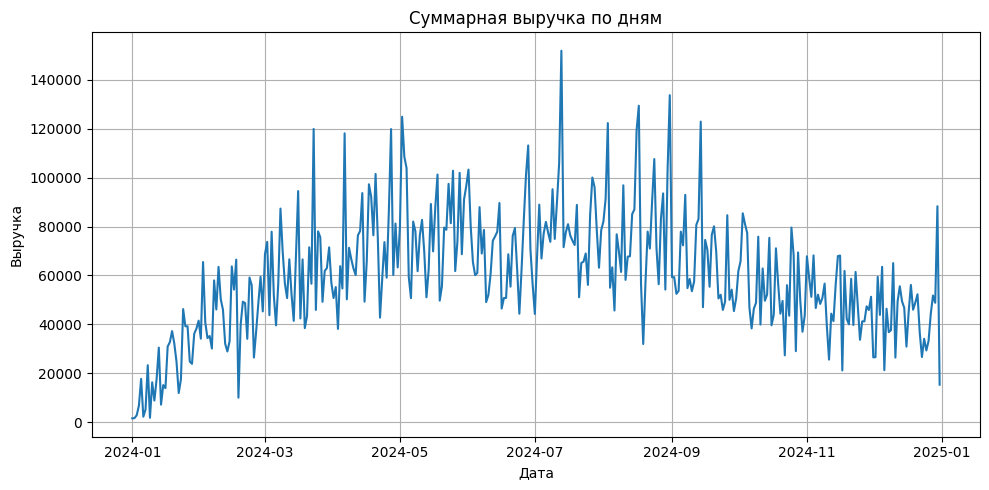

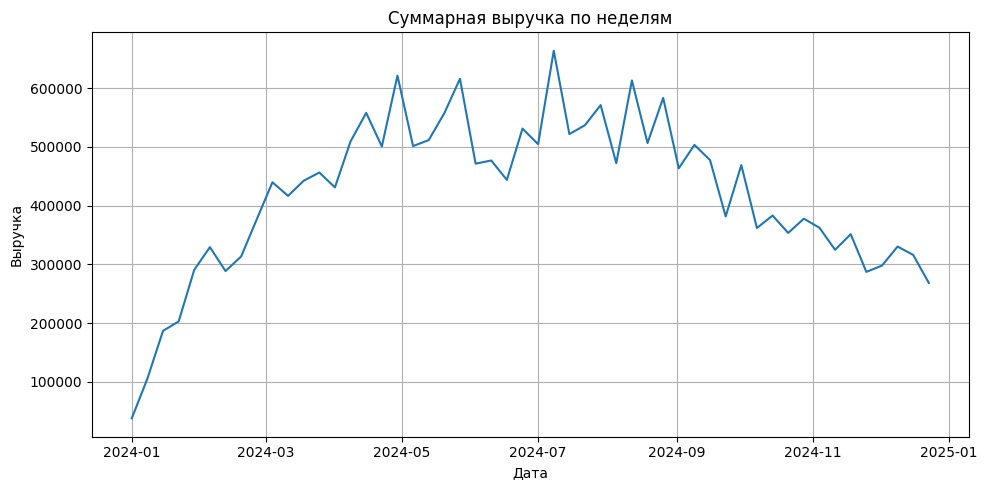

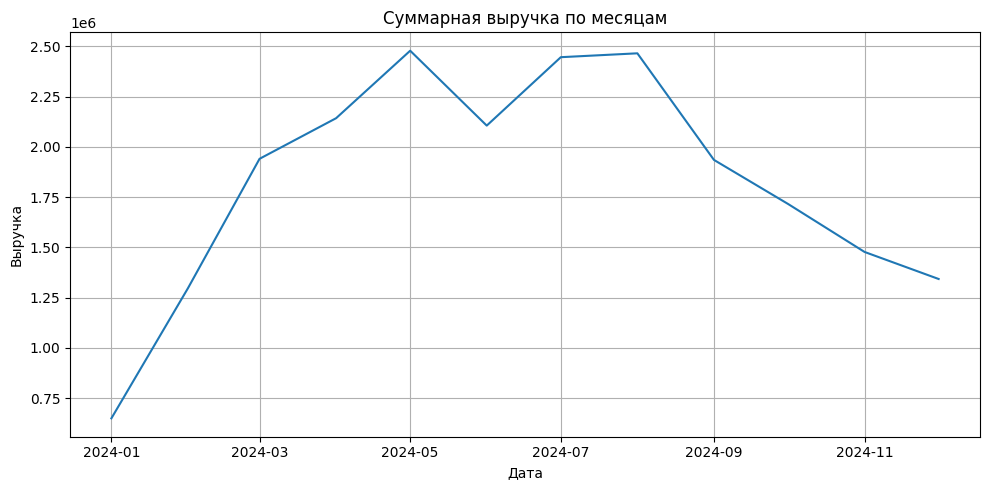

In [21]:
# Добавим столбцов для расчета метрик
orders['revenue'] = (orders['total_price'] * 0.05).round(2)
orders['order_day'] = pd.to_datetime(orders['order_date'].dt.date)

# Посмотрим выручку по дням, неделям и месяцам
periods = [
    ('Суммарная выручка по дням', 'order_day'),
    ('Суммарная выручка по неделям', 'order_week'),
    ('Суммарная выручка по месяцам', 'order_month')
]
for (title, period) in periods:
    df_plot = orders.groupby(period, as_index=False)['revenue'].sum()
    if period == 'order_week': # убираем последнюю неполную неделю
        df_plot = df_plot.iloc[:-1]

    plt.figure(figsize=(10,5))
    sns.lineplot(
        data=df_plot,
        x=period,
        y='revenue',
        ci=None
    )

    plt.title(title)
    plt.xlabel('Дата')
    plt.ylabel('Выручка')

    plt.grid(.4)
    plt.tight_layout()

**Выводы:**
- Судя по динамике дневной и недельной выручки, в поведении пользователей просматривается цикличность. Цикличность присутствует как внутри недели, так и внутри месяца. Обусловлены они скорее всего выходными и графиком начиследний зарплат.
- Так же на графиках виден явный нисходящий тренд, начавшийся примерно с августа-сентября. Возможно падение выручки связано с падением активности пользователей или снижением их серднего чека.
- Так же стоит проверить общую воронку до завершения заказа.

#### Воронка от показа товара до завершенной покупки

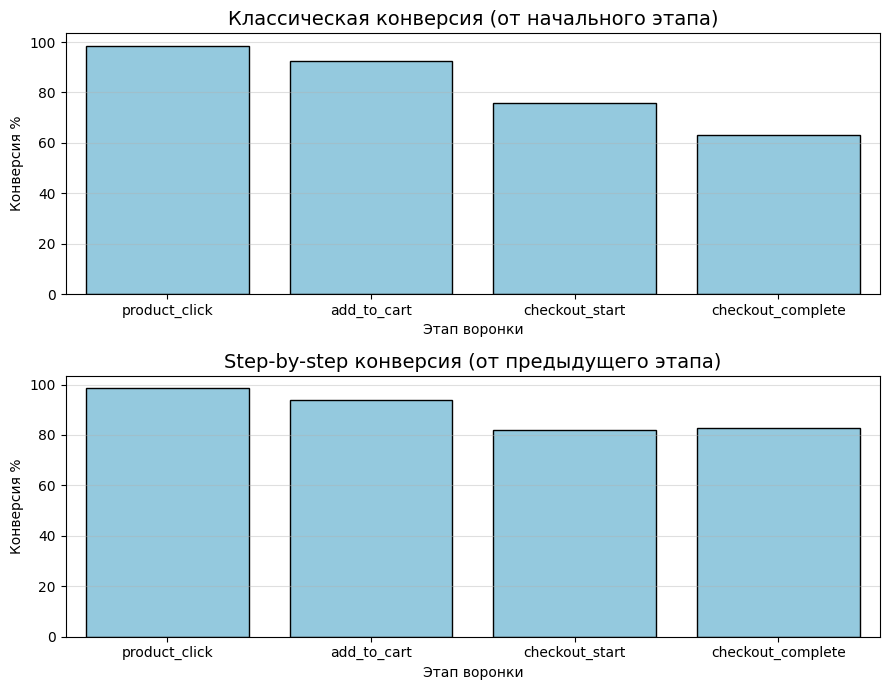

In [22]:
# Шаги воронки
funnel_steps = ['product_view', 'product_click', 'add_to_cart', 'checkout_start', 'checkout_complete']

# Фильтруем датасет и считаем уникальных пользоваталей для каждого этапа
funnel_steps_df = events[events['event_type'].isin(funnel_steps)]
funnel_counts = funnel_steps_df.groupby('event_type')['user_id'].nunique().reindex(funnel_steps)

# Создаем новый датафрейм для воронки
funnel_df = pd.DataFrame({
    'step': funnel_steps,
    'users': funnel_counts.values
})

# Считаем классическую и step-by-step конверсии
funnel_df['classic_conversion'] = funnel_df['users'] / funnel_df['users'].iloc[0] * 100
funnel_df['step_by_step'] = funnel_df['users'] / funnel_df['users'].shift(1) * 100

# Создаем два холста
fig, ax = plt.subplots(2, 1, figsize=(9, 7))

# Рисуем графики
sns.barplot(
    data=funnel_df[1:],
    x='step',
    y='classic_conversion',
    ax=ax[0],
    color='skyblue', edgecolor='black'
)
ax[0].grid(axis='y',alpha=.4)
ax[0].set_title('Классическая конверсия (от начального этапа)', fontsize=14)
ax[0].set_xlabel('Этап воронки')
ax[0].set_ylabel('Конверсия %')

sns.barplot(
    data=funnel_df[1:],
    x='step',
    y='step_by_step',
    ax=ax[1],
    color='skyblue', edgecolor='black'
)
ax[1].grid(axis='y',alpha=.4)
ax[1].set_title('Step-by-step конверсия (от предыдущего этапа)', fontsize=14)
ax[1].set_xlabel('Этап воронки')
ax[1].set_ylabel('Конверсия %')

plt.tight_layout()
plt.show()

В показателях воронки аномалий не видно.

#### DAU, WAU, MAU

Рассмотрим активность пользователей по дням, неделям и месяцам.

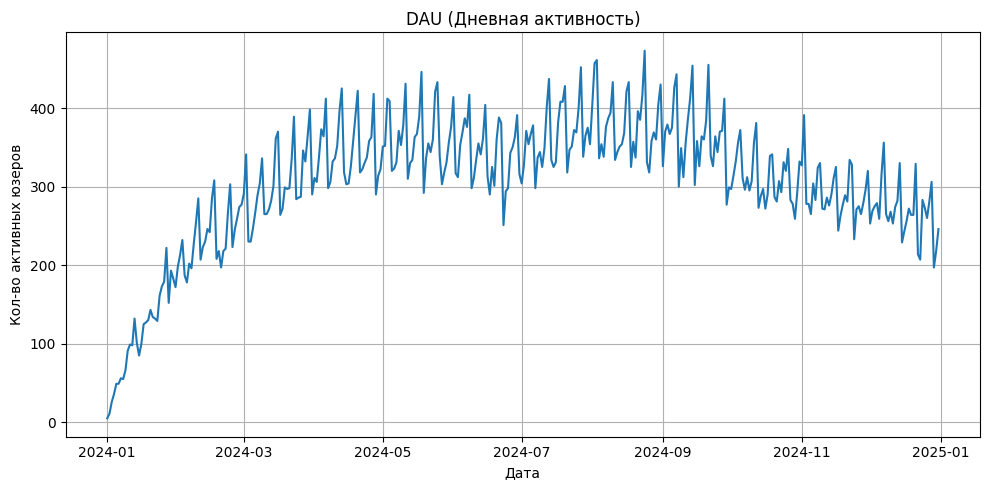

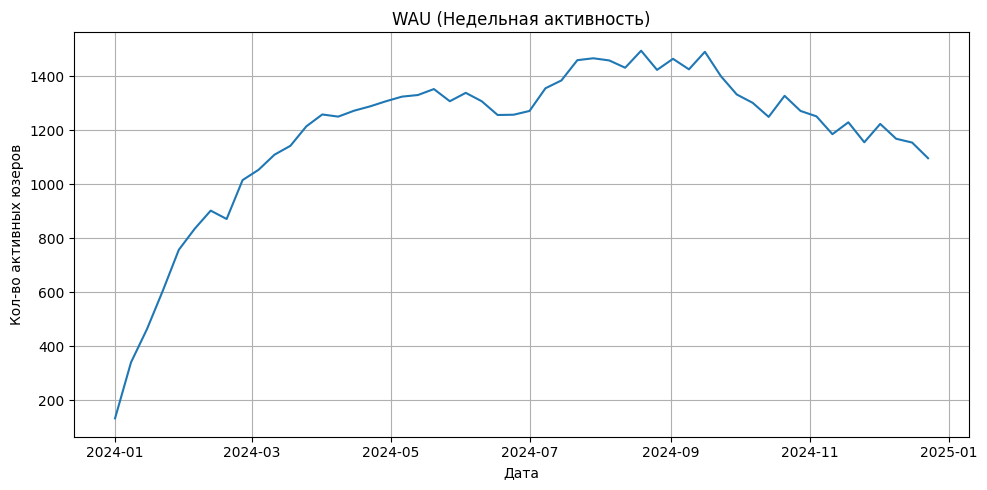

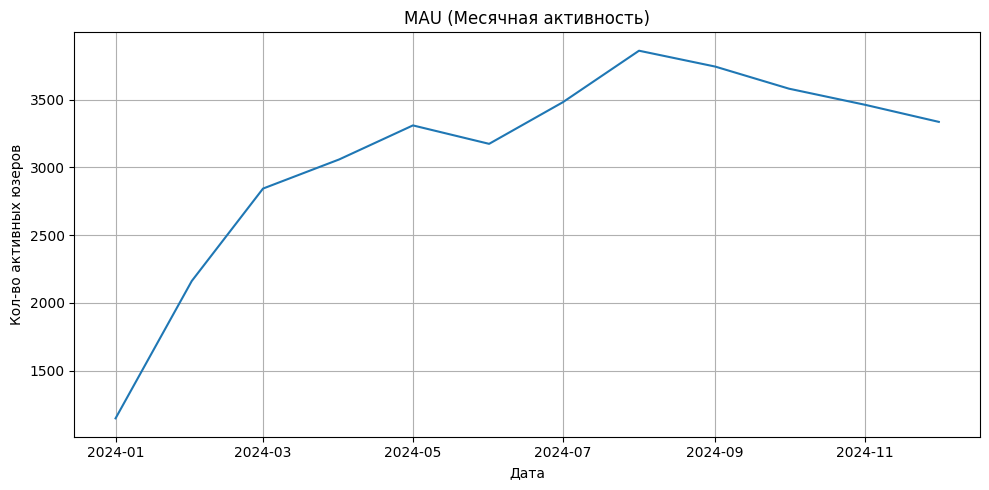

In [23]:
# Список с названиями и периодами метрик
metrics = [
    ('event_date', 'DAU (Дневная активность)'),
    ('event_week', 'WAU (Недельная активность)'),
    ('event_month', 'MAU (Месячная активность)')
]
# Рисуем график
for (period, title) in metrics:
    df_plot = events.groupby(period, as_index=False)['user_id'].nunique()
    if period == 'event_week':
        df_plot = df_plot.iloc[:-1]

    plt.figure(figsize=(10,5))
    sns.lineplot(
        data=df_plot,
        x=period,
        y='user_id'
    )

    plt.title(title)
    plt.xlabel('Дата')
    plt.ylabel('Кол-во активных юзеров')

    plt.grid(.4)
    plt.tight_layout()

**Выводы:**
- На графике `DAU` виден похожий паттерн, что и на графике суммарной дневной выручки. Явно прослеживается цикличность.
- График `WAU` уже более гладкий, чем график недельной выручки. Видимо в течении месяца пользователи заходят в продукт более-менее регулярно, но покупки делают в основном под начиследние аванса и зарплаты, что логично.
- Так же на всех трех гарфиках виден нисходящий тренд, но уже не такой категоричный, как на графиках выручки. Т.е. уменьшение выручки связано не только с уменьшением активности пользователей. Нужно продолжать исследования.

#### ARPU, ARPPU, AOV

Продолжим исследование и посчитаем месячные выручки на кадого пользователя, платящего пользователя и средний чек.

In [24]:
# Считаем выручку, платящих пользователей и средний чек за каждый месяц
finance_df = orders.groupby('order_month').agg(
    revenue_sum = ('revenue', 'sum'),
    paying_users = ('user_id', 'nunique'),
    AOV = ('total_price', 'mean')
).rename_axis('month')

# Общее кол-во активных пользователей за месяц
active_users = events.groupby('event_month').agg(
    total_users = ('user_id', 'nunique')
).rename_axis('month')

# Соединяем по месяцу (индексу)
finance_df = finance_df.join(active_users).reset_index()

# Считаем метрики
finance_df['AOV'] = finance_df['AOV'].round(2)
finance_df['ARPU'] = (finance_df['revenue_sum'] / finance_df['total_users']).round(2)
finance_df['ARPPU'] = (finance_df['revenue_sum'] / finance_df['paying_users']).round(2)

finance_df

,month,revenue_sum,paying_users,AOV,total_users,ARPU,ARPPU
0,2024-01-01,648890.14,454,13462.45,1149,564.74,1429.27
1,2024-02-01,1296557.08,839,13526.94,2162,599.70,1545.36
2,2024-03-01,1940749.76,1165,13907.20,2844,682.40,1665.88
3,2024-04-01,2142838.63,1324,13718.56,3059,700.50,1618.46
4,2024-05-01,2478758.41,1404,14091.86,3310,748.87,1765.50
5,2024-06-01,2106011.79,1230,13773.79,3174,663.52,1712.20
6,2024-07-01,2446535.27,1385,14336.57,3481,702.83,1766.45
7,2024-08-01,2465802.55,1385,14534.64,3861,638.64,1780.36
8,2024-09-01,1935366.81,1163,14044.75,3744,516.92,1664.12
9,2024-10-01,1716108.65,999,13850.75,3581,479.23,1717.83


Даже по таблице видно, что есть спад выручки на каждого пользователя. При этом средний чек и выручки на покупателя сильно не менялись.

Предлагаю для удобства визуализации посчитать выручку со среднего чека, чтобы порядок чисел был схожим и можно было отобразить все на одном графике. Метрику можно назвать `Average Revenue Value (ARV)` по аналогии с `AOV`.

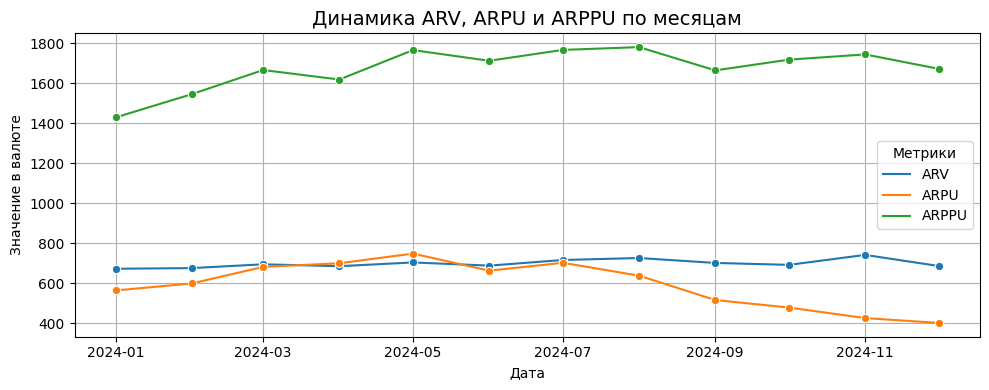

In [25]:
# Считаем метрику и преобразуем таблицу, чтобы построить график в одну строку
finance_df['ARV'] = finance_df['AOV'] * 0.05
df_plot = finance_df.melt(
    id_vars='month', 
    value_vars=['ARV', 'ARPU', 'ARPPU'], 
    var_name='metric', 
    value_name='value'
)

# Рисуем график
plt.figure(figsize=(10, 4))

sns.lineplot(data=df_plot, x='month', y='value', hue='metric', marker='o')

plt.title('Динамика ARV, ARPU и ARPPU по месяцам', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Значение в валюте')
plt.legend(title='Метрики')
plt.grid(.4)

plt.tight_layout()

**Выводы:**
- На графике видно, что заметное снижение есть только в метрике `ARPU`. Таким образом получается, что средний чек и выручка на платящего пользователя не падала, в то время, когда падала общая выручка (примерно август-сентябрь).
- По всей видимости поведение платящих пользователей сильно не изменилось, а вот конверсия в покупку у новых пользователей должна была заметно упасть.

#### Retention, CR в заказ

Рассмотрим конверсию в заказ и возврат пользователей в продукт по месячным когортам.

- **CR в заказ**

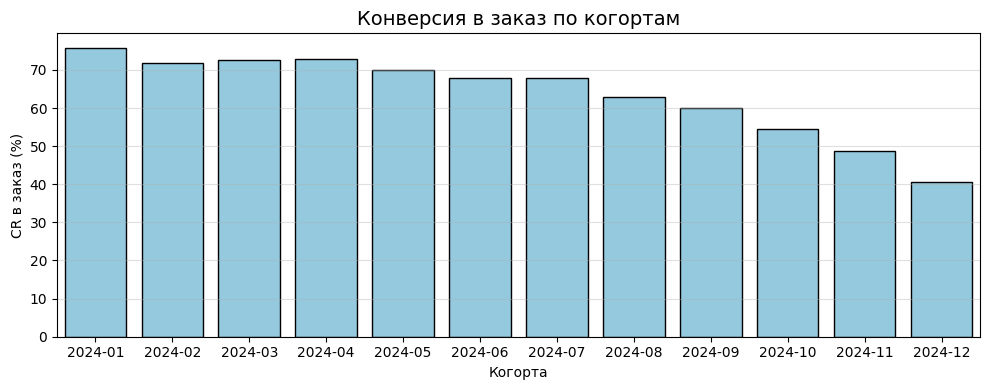

In [26]:
# Создадим столбцы с первой датой и месяцем появления в датасете
events['first_date'] = events.groupby('user_id')['event_date'].transform('min')
events['first_month'] = events['first_date'].dt.to_period('M')

# Считаем пользователей и покупателей по месяцам, соединяем по индексам и считаем конверсию
user_count = events.groupby('first_month').agg(total_users=('user_id', 'nunique'))
buyers_count = events[events['event_type'] == 'checkout_complete'].groupby('first_month').agg(total_buyers=('user_id', 'nunique'))

cohorts = user_count.join(buyers_count).reset_index()
cohorts['conversion'] = cohorts['total_buyers'] / cohorts['total_users'] * 100

# Рисуем график
plt.figure(figsize=(10, 4))
sns.barplot(data=cohorts, x='first_month', y='conversion', color='skyblue', edgecolor='black' )

plt.title('Конверсия в заказ по когортам', fontsize=14)
plt.xlabel('Когорта')
plt.ylabel('CR в заказ (%)')
plt.grid(axis='y', alpha=.4)

plt.tight_layout()

- Судя по графику снижение конверсии началось еще в мае, но возросшая выручка на каждого покупателя не дала общей вырчке упасть.
- Начиная с августа конверсия начала заметно уменьшаться у каждой когорты. Возможно продукт не отвечает потребностям новых пользователей. Можно посмотреть еще на retention для более полной картины.

- **Retention**

Я решил посмотреть retention за 8 дней, потому что на графиках выше наблюдалась примерно недельная цикличность.

Так же нужно отсечь последнюю когорту, потому что не все пользователи в ней могли успеть набрать 8 дней активности.

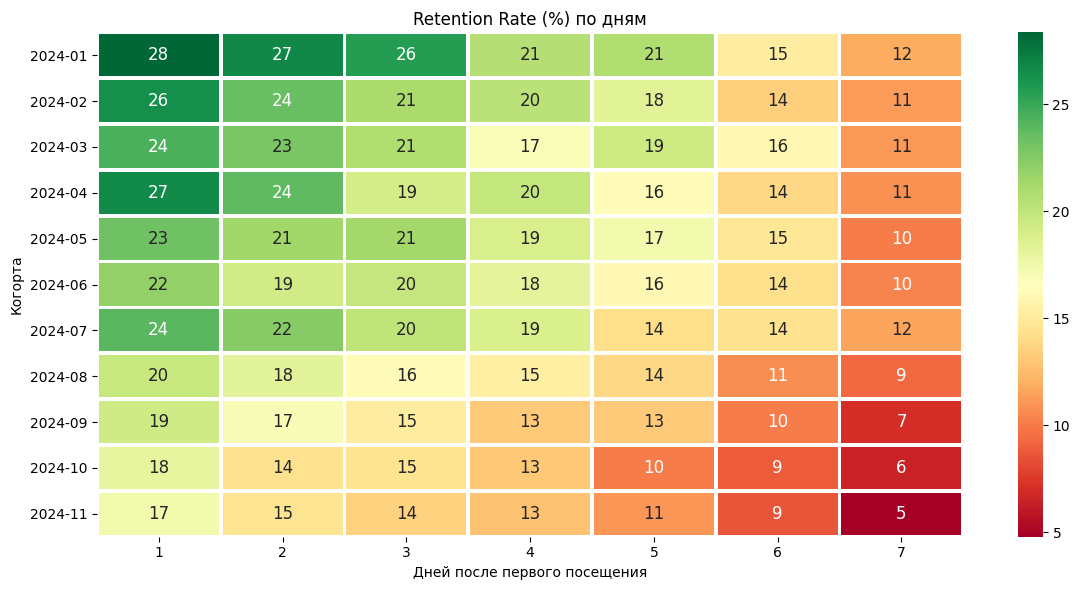

In [27]:
# Считаем дни с первого события и фильтруем датасет
events['days_delta'] = (events['event_date'] - events['first_date']).dt.days
events_filt = events[events['days_delta'] < 8]

# Считаем пользователей
df_pivot = events_filt.pivot_table(
    index = 'first_month',
    columns = 'days_delta',
    values = 'user_id',
    aggfunc = 'nunique'
)

df_pivot_retention = df_pivot.div(df_pivot[0], axis=0)*100


# Рисуем график
plt.figure(figsize=(12, 6))

sns.heatmap(
    df_pivot_retention.iloc[:-1,1:], # Уберем последнюю когорту и нулевой период
    cmap='RdYlGn',
    annot=True,
    fmt='.0f',
    linewidths=2,
    annot_kws={"size": 12}
)

plt.title('Retention Rate (%) по дням')
plt.xlabel('Дней после первого посещения')
plt.ylabel('Когорта')

plt.tight_layout()

**Выводы:**
- График `Retention` так же показывает, что, начиная с августа, пошел сильный спад возвращений в продукт. А спустя неделю в новых когортах остается в два раза меньше людей (в процентном отношении).
- Судя по графикам `CR в покупку` и `Retention` у новых когорт проблемы с заинтересованностью в продукте. Нужно выяснить в каких сегментах кроется проблема. 

Посчитаем разницу в цифрах

In [28]:
revenue_df = orders.groupby('order_month', as_index=False)['revenue'].sum()
users_df = events.groupby('event_month', as_index=False)['user_id'].nunique()

print(f'''
Разница в процентах в выручке между июлем и декабрем: {abs(revenue_df.iloc[6,1] - revenue_df.iloc[-1,1]) / revenue_df.iloc[6,1]:.2%}
Активность пользователей с августа по декабрь упала на {abs(users_df.iloc[7,1] - users_df.iloc[-1,1]) / users_df.iloc[6,1]:.2%}
''')


Разница в процентах в выручке между июлем и декабрем: 45.13%
Активность пользователей с августа по декабрь упала на 15.08%



**Общие выводы по ключевым метрикам:**
- Начиная с августа наблюдается серьезный тред на снижение общей выручки. С июля по декабрь выручка упала на 45%.
- При этом платящие пользователи не стали платить меньше, снизилась только выручка на каждого пользователя.
- Начиная с сентября в продукте стало меньше активных пользователей. С августа по декабрь активных пользователей стало меньше на 15%.
- Так же начиная с августа начала падать конверсия в покупку. И люди стали заметно меньше возвращаться в продукт в течении первой недели. В начале года в продукте спустя неделю оставалось 12% пользователей, а в конце года - только 5%

### 3. Оценка метрик монетизации и юнит-экономики

Выполним анализ монетизации. Определим, сколько зарабатывает продукт и сколько тратит на привлечение.

- **CAC**

Посчитаем САС для каждой месячной когорты и канала привлечения

In [29]:
# Считаем пользователей по месячным когортам и каналам и объединяем с затратами
cohort_df = users.groupby(['cohort_month', 'acq_channel'], as_index=False)['user_id'].nunique()
df_CAC = costs.merge(cohort_df, right_on=['cohort_month', 'acq_channel'], left_on=['spend_month', 'acq_channel'], how='left')

# Считаем метрику
df_CAC['CAC'] = df_CAC['budget'] / df_CAC['user_id']

# Добавляем столбец CAC в датасет users
users = users.merge(df_CAC[['cohort_month', 'acq_channel', 'CAC']], on=['cohort_month', 'acq_channel'])

# Проверяем
df_info(users)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 44151 entries, 0 to 44150
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            44151 non-null  int64         
 1   registration_date  44151 non-null  datetime64[ns]
 2   age                44151 non-null  int64         
 3   gender             44151 non-null  object        
 4   region             44151 non-null  object        
 5   acq_channel        44151 non-null  object        
 6   buyer_segment      44151 non-null  object        
 7   cohort_week        44151 non-null  datetime64[ns]
 8   cohort_month       44151 non-null  datetime64[ns]
 9   CAC                44151 non-null  float64       
dtypes: datetime64[ns](3), float64(1), int64(2), object(4)
memory usage: 3.7+ MB


None

------------------------------------------------------------------------------------------


,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month,CAC
0,1,2024-01-01 00:47:00,35,M,Москва,Google Ads,regular,2024-01-01,2024-01-01,500.335847
1,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01,500.335847
2,5,2024-01-01 08:29:00,58,F,Другие регионы,Google Ads,regular,2024-01-01,2024-01-01,500.335847
3,14,2024-01-01 02:21:00,19,M,Нижний Новгород,Google Ads,medium,2024-01-01,2024-01-01,500.335847
4,21,2024-01-01 06:42:00,63,F,Санкт-Петербург,Google Ads,medium,2024-01-01,2024-01-01,500.335847


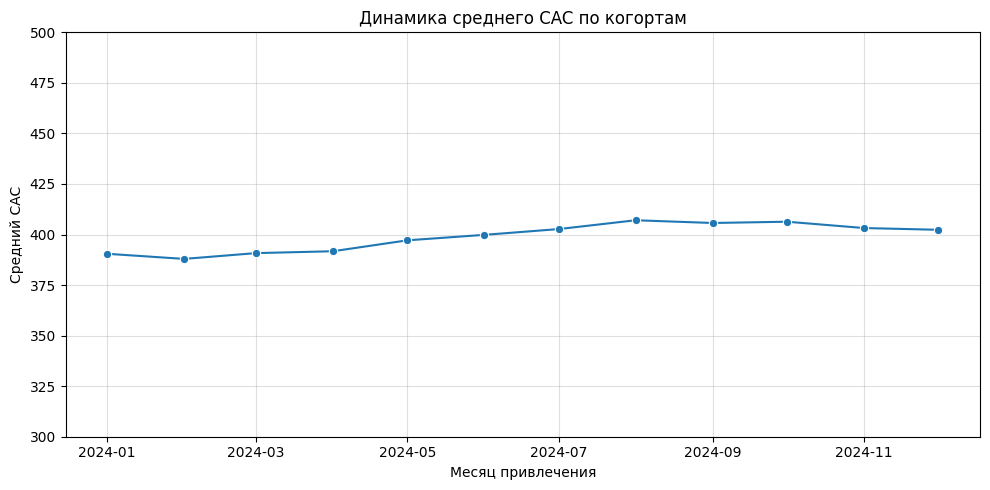

In [30]:
# Считаем средний CAC на когорту
cohort_CAC = users.groupby('cohort_month', as_index=False).agg(avg_CAC=('CAC', 'mean'),
                                                               user_count=('user_id', 'nunique')) # чтобы потом посчитать LTV

# Рисуем график
plt.figure(figsize=(10,5))
sns.lineplot(
    data=cohort_CAC,
    x='cohort_month',
    y='avg_CAC',
    marker='o'
)

# Настройки отображения
plt.grid(alpha=.4)
plt.ylim(300,500)
plt.title('Динамика среднего CAC по когортам')
plt.xlabel('Месяц привлечения')
plt.ylabel('Средний CAC')
plt.tight_layout()

- Как можно видеть из графика средний САС на когорту незначительно увеличивался до августа, а затем, также незначительно, пошел на спад.

- **LTV**

Далее нужно посчитать накопленный LTV за месяц для каждой когорты, кроме последней.

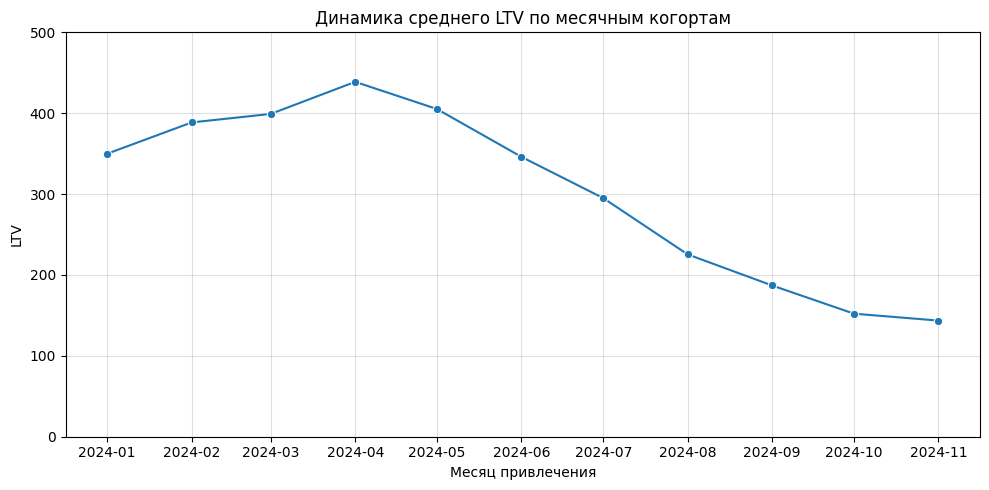

In [31]:
# Объединяем inner'ом, потому что нас интересуют только пользователи, которые регистрировались в 24м году.
cohort_orders = orders.merge(users[['user_id', 'cohort_month', 'cohort_week', 'registration_date', 'acq_channel']], on='user_id')
# Добавляем столбец с разницей в дняъ со дня регистрации
cohort_orders['days_delta'] = (
    cohort_orders['order_date'].dt.to_period('D').astype('int') - cohort_orders['registration_date'].dt.to_period('D').astype('int')
)

# Фильтруем первые 30 дней группируем по первому месяцу
orders_group = cohort_orders[cohort_orders['days_delta'].between(0,29)].groupby('cohort_month', as_index=False)['revenue'].sum()

# Объединяем получившуюся таблицу с cohort_CAC по первому месяцу активности
cohort_LTV_CAC = pd.merge(orders_group, cohort_CAC, on='cohort_month')

# Делим сумму выручки на общее количество пользователей в когорте
cohort_LTV_CAC['LTV'] = cohort_LTV_CAC['revenue'] / cohort_LTV_CAC['user_count']

# Рисуем график LTV
plt.figure(figsize=(10,5))
sns.lineplot(
    data=cohort_LTV_CAC.iloc[:-1], # Убираем последнюю когорту, потому что там не все накопили по 30 дней активности
    x='cohort_month',
    y='LTV',
    marker='o'
)

plt.grid(alpha=.4)
plt.ylim(0,500)
plt.title('Динамика среднего LTV по месячным когортам')
plt.xlabel('Месяц привлечения')
plt.ylabel('LTV')
plt.tight_layout()

Накопленный LTV за месяц снижался, начиная с апрельской когорты. С апреля по ноябрь LTV упал более чем в два раза. 

- **ROI**

Посмотрим, какие когорты успели окупиться за месяц

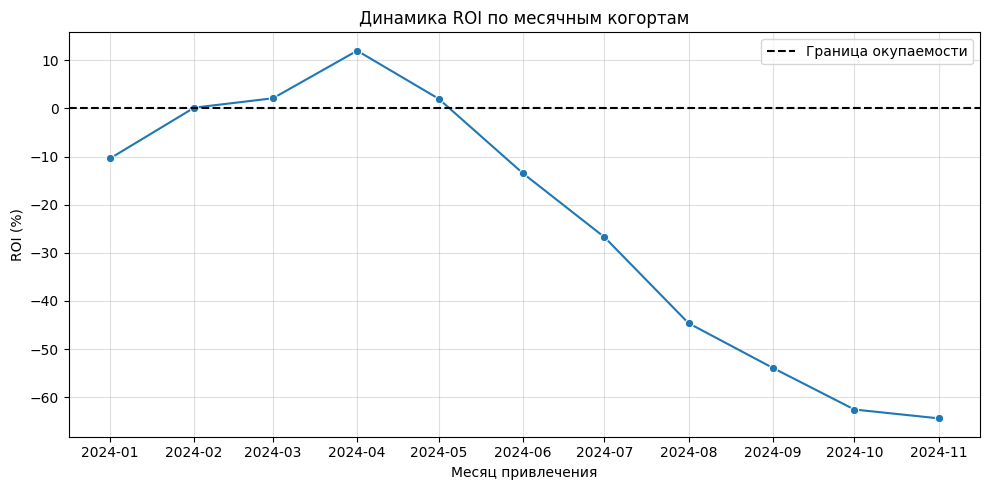

In [32]:
# Считаем ROI
cohort_LTV_CAC['ROI'] = (cohort_LTV_CAC['LTV'] - cohort_LTV_CAC['avg_CAC']) / cohort_LTV_CAC['avg_CAC'] * 100

# Рисуем график
plt.figure(figsize=(10,5))
sns.lineplot(
    data=cohort_LTV_CAC.iloc[:-1],
    x='cohort_month',
    y='ROI',
    marker='o'
)

# Рисуем линию окупаемости y=0
plt.axhline(y=0, color='black', linestyle='--', label='Граница окупаемости')

plt.grid(alpha=.4)
plt.legend()
plt.title('Динамика ROI по месячным когортам')
plt.xlabel('Месяц привлечения')
plt.ylabel('ROI (%)')
plt.tight_layout()

Границу окупаемости за месяц активности смогли пересечь только весенние когорты.

Нужно посмотреть дальше месяца. Может они окупаются позже.

- **Payback Period**

Рассмотрим накопительный ROI для месячных когорт в периоде 10 недель.

In [33]:
# Расчитываем периоды и фильтруем первые 10
cohort_orders['week_delta'] = (
    cohort_orders['order_week'].dt.to_period('W').astype('int') - cohort_orders['cohort_week'].dt.to_period('W').astype('int')
)

orders_filt = cohort_orders[cohort_orders['week_delta'].between(0,9)]

# Считаем выручку для каждой когорты по периодам
cohort_revenue = orders_filt.groupby(['cohort_month', 'week_delta'], as_index=False)['revenue'].sum()

# Отсортируем таблицу и посчтаем кумулятивную сумму выручки
cohort_revenue.sort_values(by=['cohort_month', 'week_delta'], inplace=True)
cohort_revenue['revenue_cumsum'] = cohort_revenue.groupby('cohort_month')['revenue'].cumsum()

# Объединяем таблицы и считаем LTV
cohort_LTV_CAC = cohort_revenue.merge(cohort_CAC, on='cohort_month')
cohort_LTV_CAC['LTV'] = cohort_LTV_CAC['revenue_cumsum'] / cohort_LTV_CAC['user_count']

# Считаем ROI 
cohort_LTV_CAC['ROI'] = (cohort_LTV_CAC['LTV'] - cohort_LTV_CAC['avg_CAC']) / cohort_LTV_CAC['avg_CAC']

# Форматируем поле cohort_month в строку, для отображения на тепловой карте
cohort_LTV_CAC['cohort_month'] = cohort_LTV_CAC['cohort_month'].astype(str)

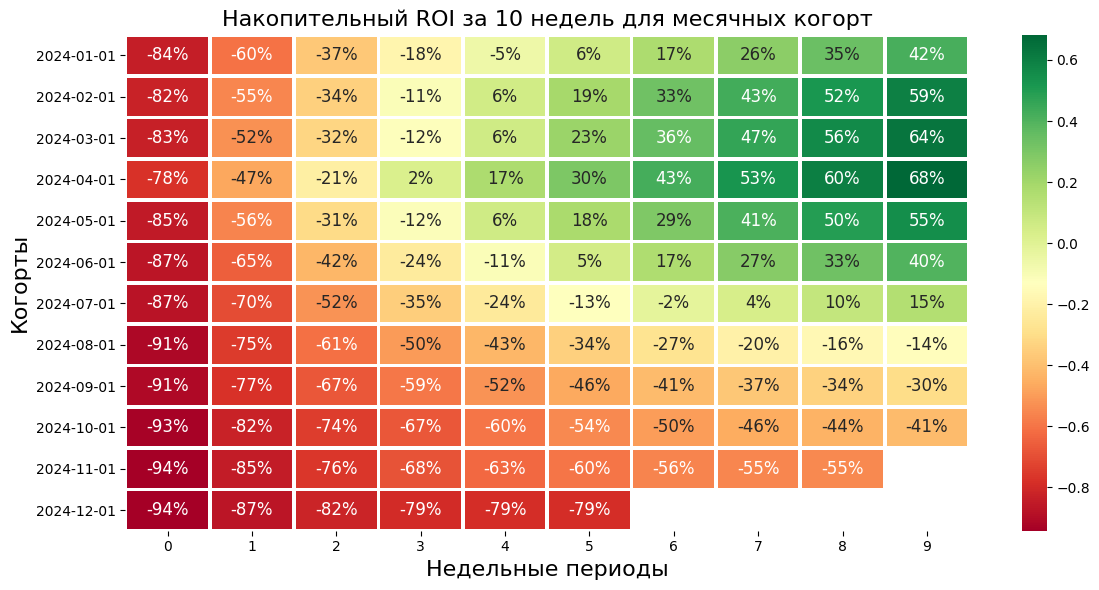

In [34]:
# Пивотируем
pivot_data = pd.pivot_table(
    cohort_LTV_CAC,
    index='cohort_month',
    columns='week_delta',
    values='ROI'
)

# Рисуем график
plt.figure(figsize=(12, 6))

sns.heatmap(
    pivot_data,
    cmap='RdYlGn',
    annot=True,
    fmt='.0%',
    linewidths=2,
    annot_kws={"size": 12}
)

plt.title('Накопительный ROI за 10 недель для месячных когорт', fontsize=16)
plt.xlabel('Недельные периоды', fontsize=16)
plt.ylabel('Когорты', fontsize=16)

plt.tight_layout()

Последняя когорта, которая успела окупиться в горизонте 10ти недель - июльская, она окупилась за 8 недель.

Начиная с августа когорты перестали окупаться в искомом интервале. И, если смотреть по периодам, показатели ROI тоже падают - когорта декабря показывает худшие результаты.

## Выводы по этапам 2 и 3


**Общие выводы:**
- За последние пол года суммарная месячная выручка упала практически в два раза.
- Количество активных пользователей тоже падает, но не так серьезно.
- При рассмотрении метрик ARPU, ARPPU и AOV стало видно, что падает только средняя выручка на пользователя. Т.е. поведение покупателей не изменилось - они не стали меньше тратить, просто покупателей стало меньше.
- Конверсия в покупку у новых пользователей стала падать каждый месяц. В начале лета она была в районе 70%, в декабре опустилась до 40%.
- Так же удержание пользователей в течении 8ми дней упало с 12% в начале года до 5% в конце года.

## 4. Поиск инсайтов, точек роста и сегментация


После того как мы провели верхнеуровневую оценку данных, самое время переходить от общей картины к точечным наблюдениям. Посмотрим вглубь данных: по каналам,
сегментам пользователей, категориям товаров, регионам, типам устройств.

Цель — сформировать обоснованные гипотезы:

* какие сегменты работают лучше остальных
* какие сегменты работают хуже остальных
* на каких этапах воронки теряются пользователи
* какие группы можно или нужно масштабировать
* куда стоит инвестировать больше внимания или ресурсов

- **Сегментированная выручка**

Посчитаем суммарную месячную выручку по разным сегментам

In [35]:
# Добавим возрастной признак каждому пользователю
users['age_group'] = pd.cut(users['age'], bins=[17, 30, 45, 60, 70], labels=['Молодежь', 'Взрослые', 'Зрелые', 'Пожилые'])

# Передадим категориальные признаки в датасет orders
orders = orders.merge(
    users[['user_id', 'gender', 'region', 'acq_channel', 'buyer_segment', 'age_group']], 
    on='user_id', 
    how='left'
)

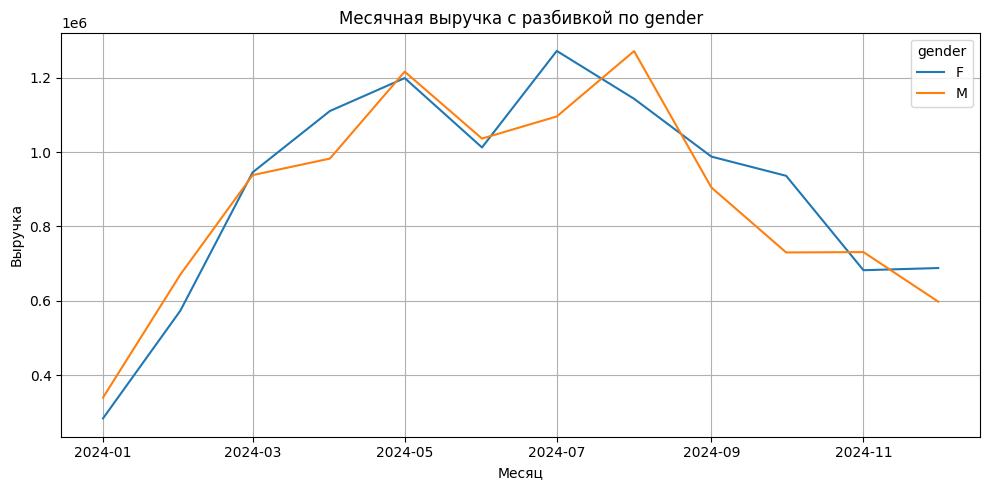

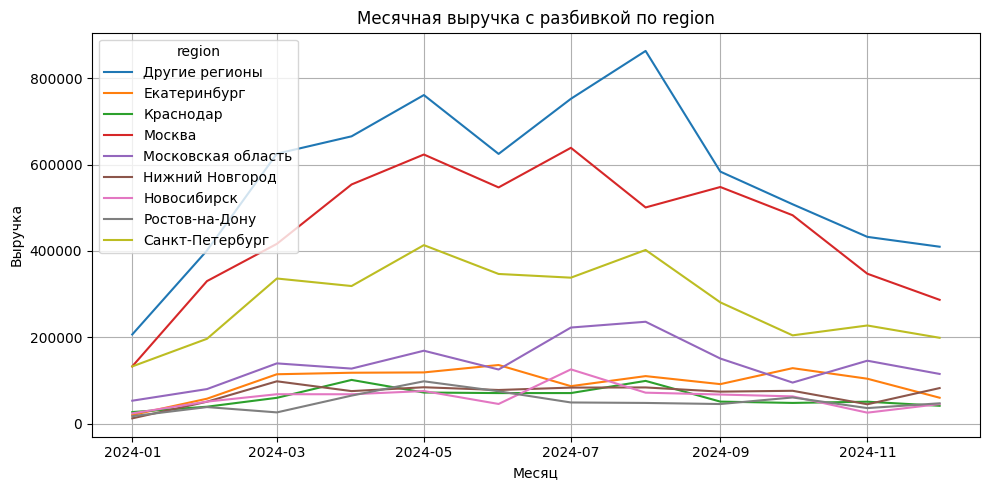

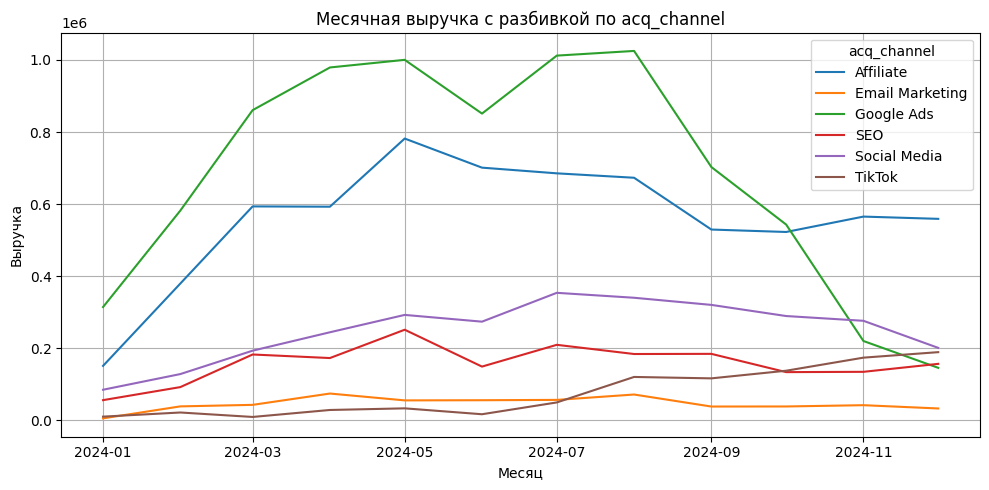

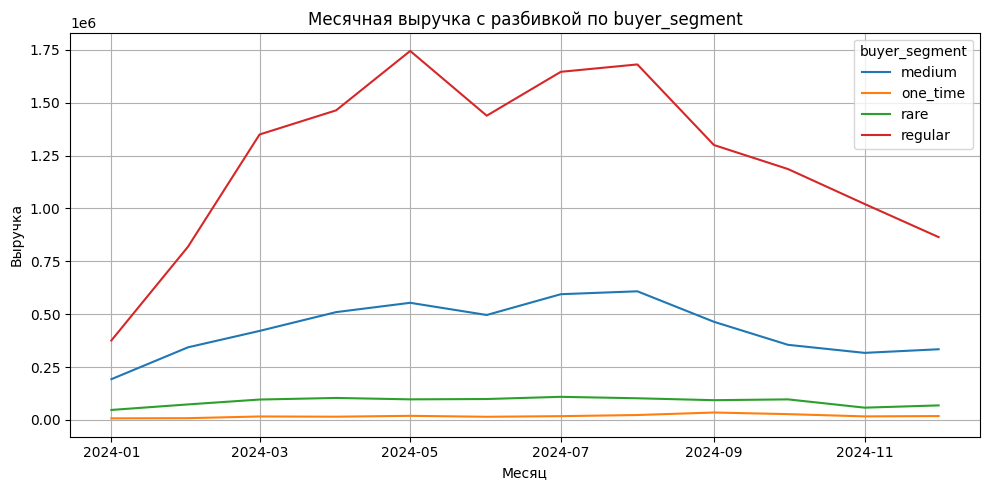

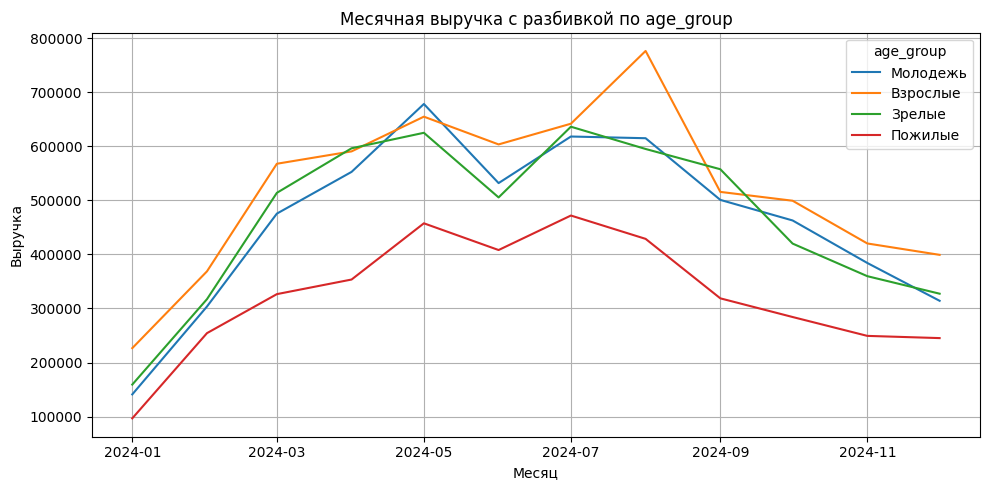

In [36]:
# Рисуем графики
for hue in ['gender', 'region', 'acq_channel', 'buyer_segment', 'age_group']:
    df_plot = orders.groupby(['order_month', hue], as_index=False)['revenue'].sum()

    plt.figure(figsize=(10,5))
    sns.lineplot(
        data=df_plot,
        x='order_month',
        y='revenue',
        hue=hue,
        ci=None
    )

    plt.title(f'Месячная выручка с разбивкой по {hue}')
    plt.xlabel('Месяц')
    plt.ylabel('Выручка')

    plt.grid(.4)
    plt.tight_layout()

Во всех вариантах сегментации, кроме каналов привлечения, наблюдается одна и та же картина - выручка падает, начиная с августа/сентября.

В каналах привлечения самое большое падение показывает канал `Google Ads`. При этом он генерировал больше всего прибыли.

Нужно посмотреть детальнее на каналы привлечения.

- **Детализация данных для каналов привлечения**

Для начала рассмотрим кол-во активных пользователей в месяц

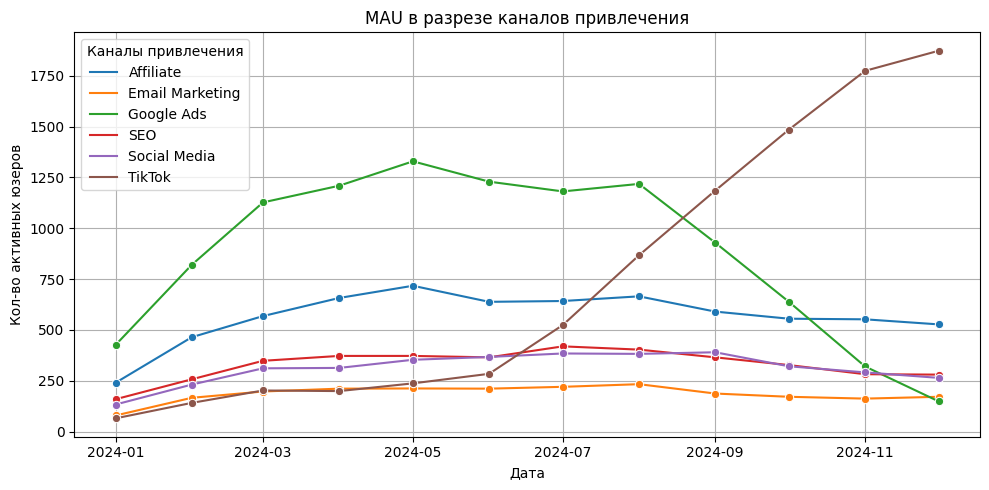

In [37]:
# Добавим в events поля из users
events = events.merge(users[['user_id', 'acq_channel', 'cohort_month']], on='user_id', how='left')

# Рисуем график
df_plot = events.groupby(['event_month', 'acq_channel'], as_index=False)['user_id'].nunique()
plt.figure(figsize=(10,5))
sns.lineplot(
    data=df_plot,
    x='event_month',
    y='user_id',
    hue='acq_channel',
    marker='o'
)

plt.title('MAU в разрезе каналов привлечения')
plt.legend(title='Каналы привлечения')
plt.xlabel('Дата')
plt.ylabel('Кол-во активных юзеров')
plt.grid(.4)
plt.tight_layout()

С сентября начинается резкое падение активных пользователей из канала `Google Ads`.

С июля начинается резкий рост кол-ва активных пользователей из канала `TikTok`. При этом на графике месячной выручки такого резкого взлета не наблюдалось.

Нужно сравнить этот график с привлеченными пользователями и потраченными бюджетами по месяцам.

In [38]:
# Кол-во пользователей, привлеченных в каждый месяц по каналам
channels_df = users.groupby(['cohort_month', 'acq_channel'])['user_id'].nunique().rename_axis(['spend_month', 'acq_channel']).reset_index()
channels_df = channels_df.merge(costs, on=['spend_month', 'acq_channel'])

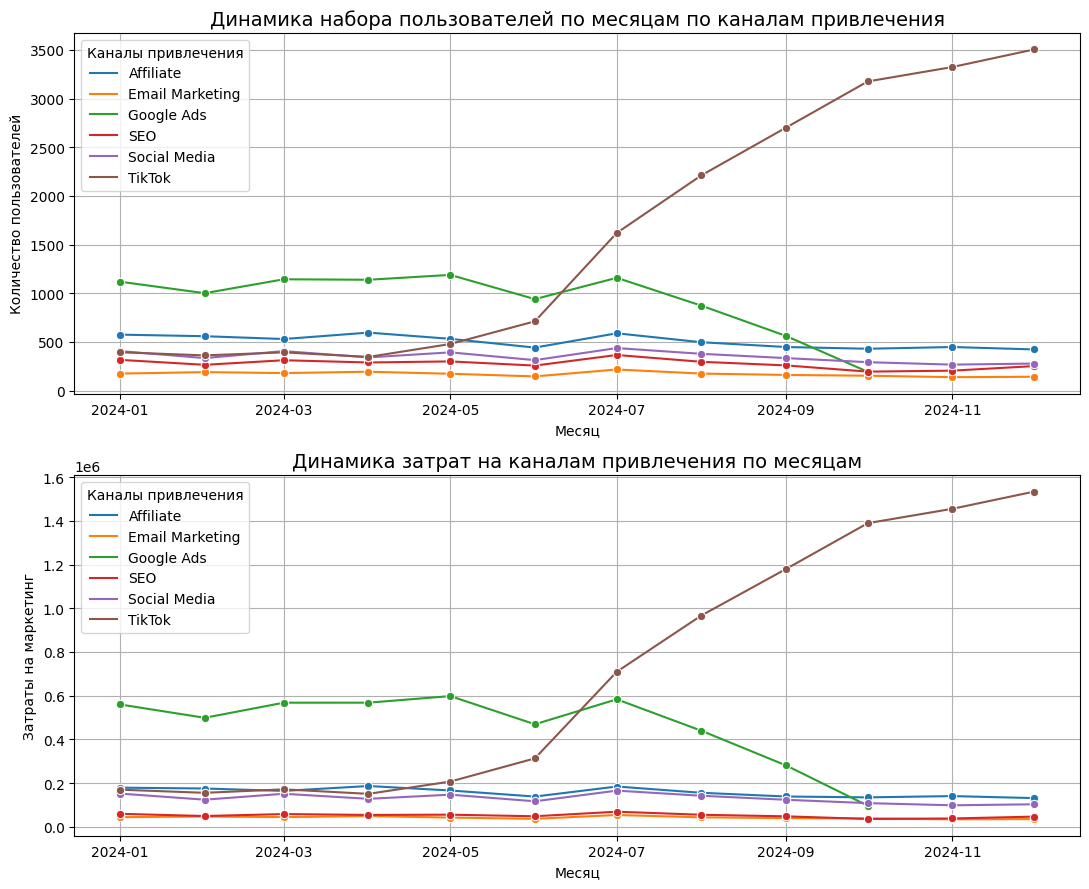

In [39]:
# Рисуем графики
fig, ax = plt.subplots(2, 1, figsize=(11, 9))

sns.lineplot(data=channels_df, x='spend_month', y='user_id', hue='acq_channel', marker='o', ax=ax[0])

ax[0].set_title('Динамика набора пользователей по месяцам по каналам привлечения', fontsize=14)
ax[0].set_xlabel('Месяц')
ax[0].set_ylabel('Количество пользователей')
ax[0].legend(title='Каналы привлечения')
ax[0].grid(.4)

sns.lineplot(data=channels_df, x='spend_month', y='budget', hue='acq_channel', marker='o', ax=ax[1])

ax[1].set_title('Динамика затрат на каналам привлечения по месяцам', fontsize=14)
ax[1].set_xlabel('Месяц')
ax[1].set_ylabel('Затраты на маркетинг')
ax[1].legend(title='Каналы привлечения')
ax[1].grid(.4)

plt.tight_layout()

Либо люди перестали приходить через канал `Google Ads`. Как я понимаю, в октябре был последний месяц, когда этот канал привлечения работал. И до этого, начиная с августа, бюджеты и количество пользоваталей начали падать.

В то же время на канал `TikTok` тратится все больше денег и по нему приходит все больше людей.

Все остальные каналы не испытывали серьезных изменений в наблюдаемый период.

Нужно посмотреть воронку и окупаемость каналов привлечения.

- **Воронки для каждого канала привлечения**

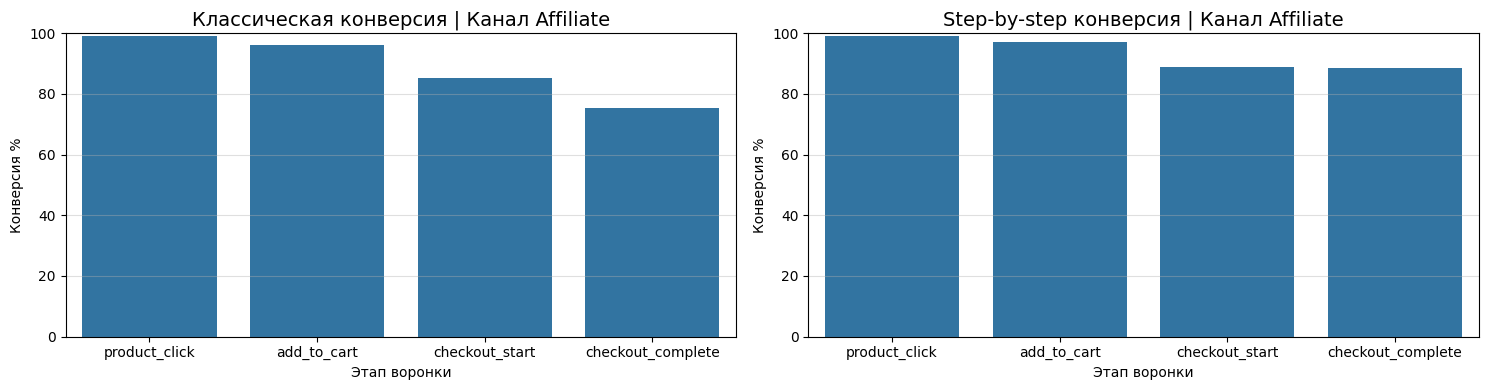

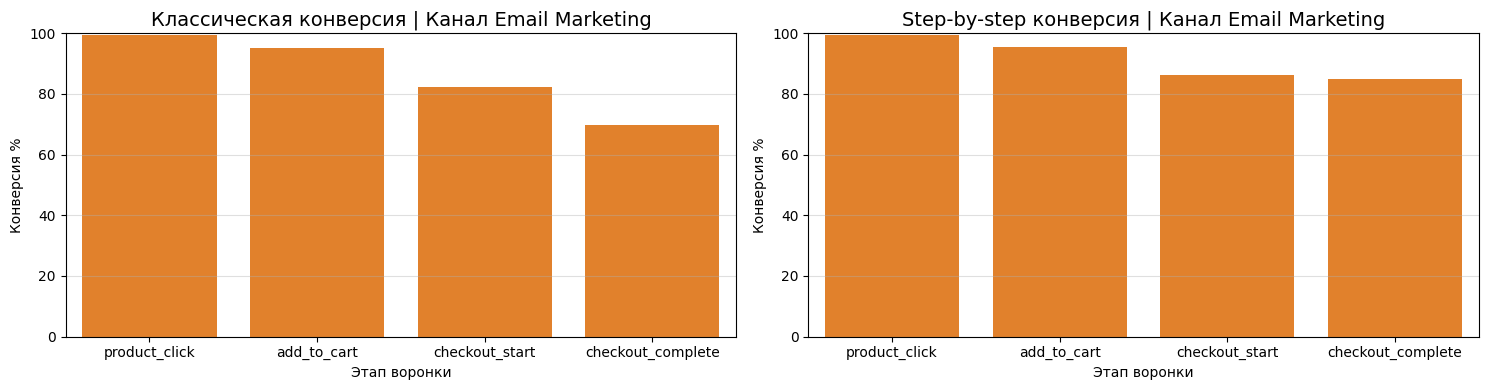

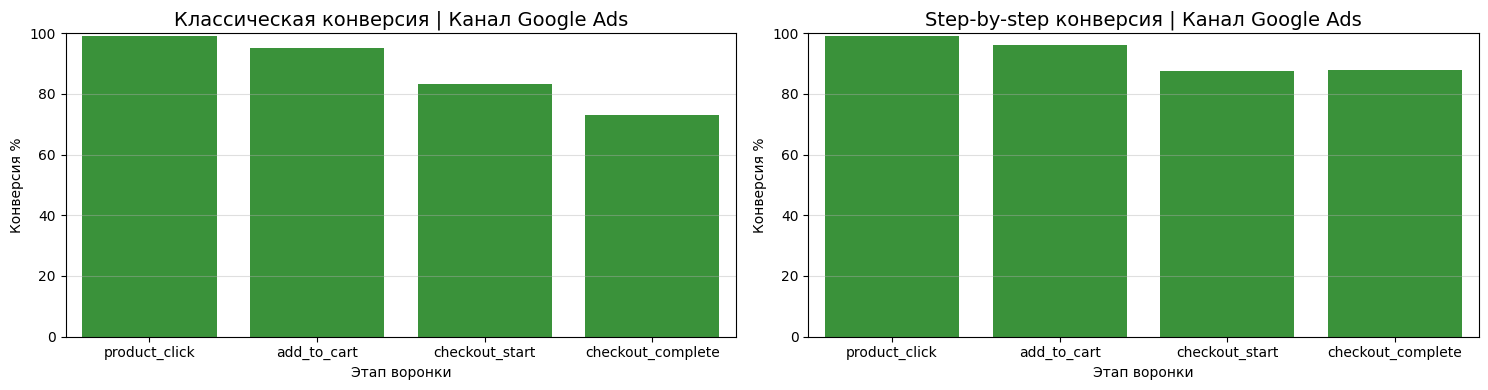

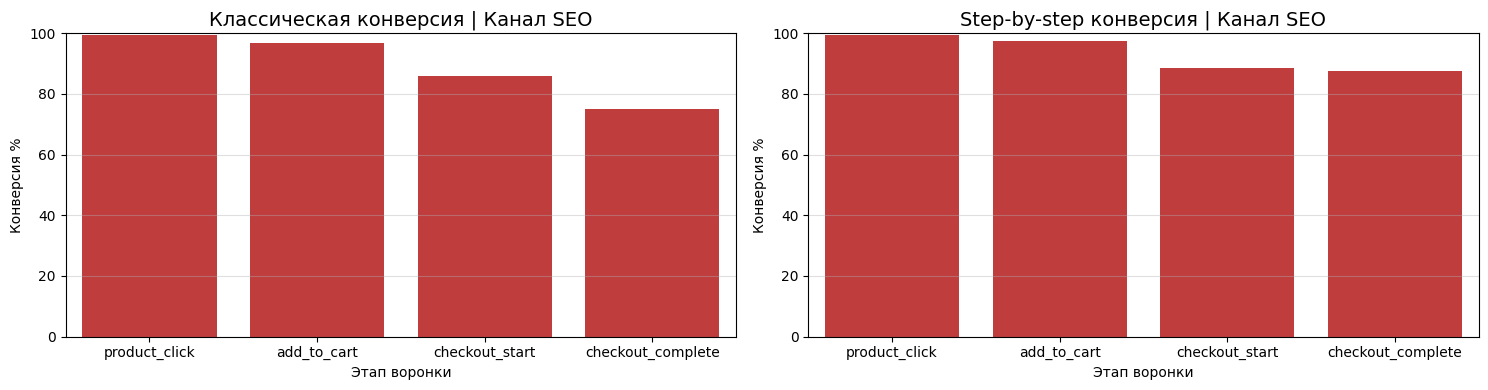

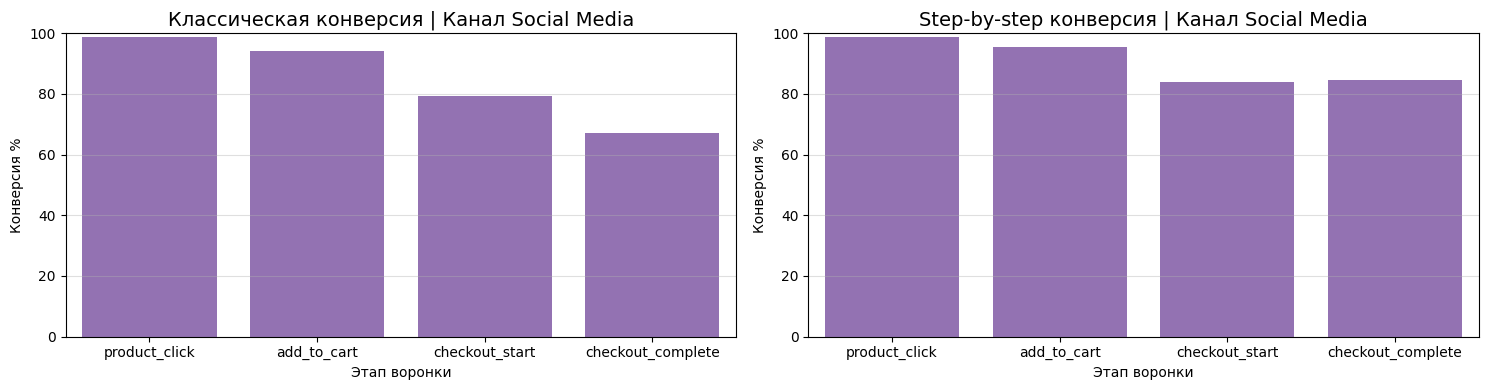

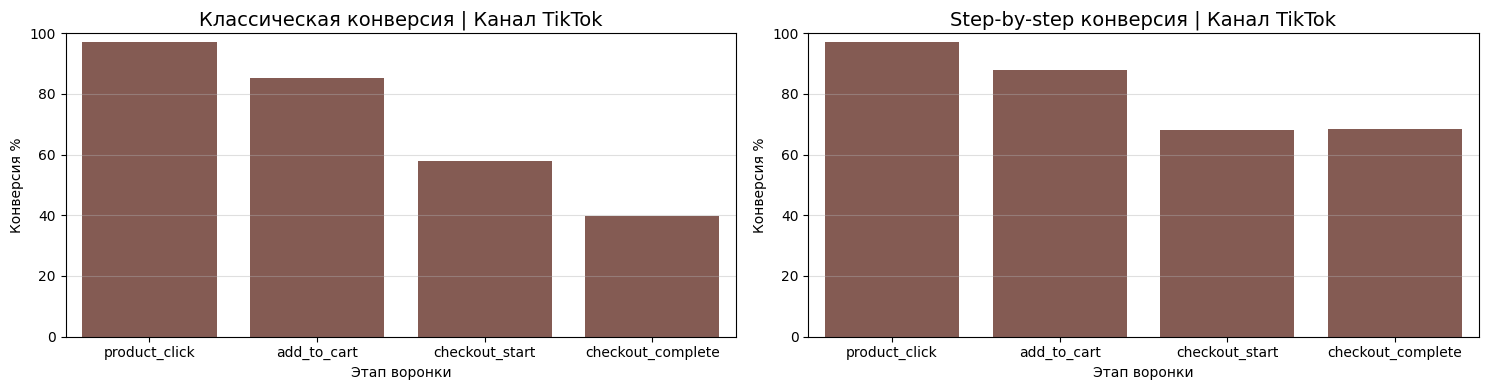

In [40]:
# Шаги воронки
funnel_steps = ['product_view', 'product_click', 'add_to_cart', 'checkout_start', 'checkout_complete']

# Палитра
colors = sns.color_palette('tab10', n_colors=len(channels_df['acq_channel'].unique()))

for i, channel in enumerate(channels_df['acq_channel'].unique()):
    current_color = colors[i]
# Фильтруем датасет и считаем уникальных пользоваталей для каждого этапа
    funnel_control_df = events[(events['event_type'].isin(funnel_steps)) &
                         (events['acq_channel'] == channel)]
    funnel_counts = funnel_control_df.groupby('event_type')['user_id'].nunique().reindex(funnel_steps)

# Создаем новый датафрейм для воронки
    funnel_df = pd.DataFrame({
        'step': funnel_steps,
        'users': funnel_counts.values
    })

# Считаем классическую и step-by-step конверсии
    funnel_df['classic_conversion'] = funnel_df['users'] / funnel_df['users'].iloc[0] * 100
    funnel_df['step_by_step'] = funnel_df['users'] / funnel_df['users'].shift(1) * 100

# Создаем два холста
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))

# Рисуем графики
    sns.barplot(
        data=funnel_df[1:],
        x='step',
        y='classic_conversion',
        ax=ax[0],
        color=current_color
    )
    ax[0].grid(axis='y',alpha=.4)
    ax[0].set_ylim(0, 100)
    ax[0].set_title(f'Классическая конверсия | Канал {channel}', fontsize=14)
    ax[0].set_xlabel('Этап воронки')
    ax[0].set_ylabel('Конверсия %')

    sns.barplot(
        data=funnel_df[1:],
        x='step',
        y='step_by_step',
        ax=ax[1],
        color=current_color
    )
    ax[1].grid(axis='y',alpha=.4)
    ax[1].set_ylim(0, 100)
    ax[1].set_title(f'Step-by-step конверсия | Канал {channel}', fontsize=14)
    ax[1].set_xlabel('Этап воронки')
    ax[1].set_ylabel('Конверсия %')

    plt.tight_layout()
    plt.show()

У всех каналов привлечения, кроме `TikTok`, от 60% до 80% пользователей, которые увидели и кликнули на товар, в итоге его купили. Так же у этих каналов конверсия из добавления в корзину в оформленный заказ больше 80%.

Пользователи из канала `TikTok` только в 40% случаев из просмотра товара переходят к его покупке. Так же люди из этого канала после добавления товара в корзину покупают его только в 60% случаев. Возможно дело в том, что трафик из Тиктока состоит из молодых людей. В датасете `users` минимальный возраст 18 лет, но я не уверен, насколько это правда.

Посмотрим на окупаемость каналов привлечения.

- **LTV по каналам привлечения**

Рассмотрим накопленный LTV по месячным когортам за 30 дней

In [41]:
# Считаем средний CAC для каждого канала по месячным когортам
cohort_CAC = users.groupby(['acq_channel', 'cohort_month'], as_index=False).agg(avg_CAC=('CAC', 'mean'),
                                                                                user_count=('user_id', 'count'))

# Отфильтровываем 30 дней активности и считаем суммарную выручку для каналов и когорт
cohorts_revenue = cohort_orders[cohort_orders['days_delta'].between(0,29)].groupby(['acq_channel', 'cohort_month'], as_index=False)['revenue'].sum()

# Объединяем таблицы и считаем метрики
cohort_LTV_CAC = pd.merge(cohorts_revenue, cohort_CAC, on=['acq_channel', 'cohort_month'])
cohort_LTV_CAC['LTV'] = cohort_LTV_CAC['revenue'] / cohort_LTV_CAC['user_count']
cohort_LTV_CAC['ROI'] = (cohort_LTV_CAC['LTV'] - cohort_LTV_CAC['avg_CAC']) / cohort_LTV_CAC['avg_CAC'] * 100

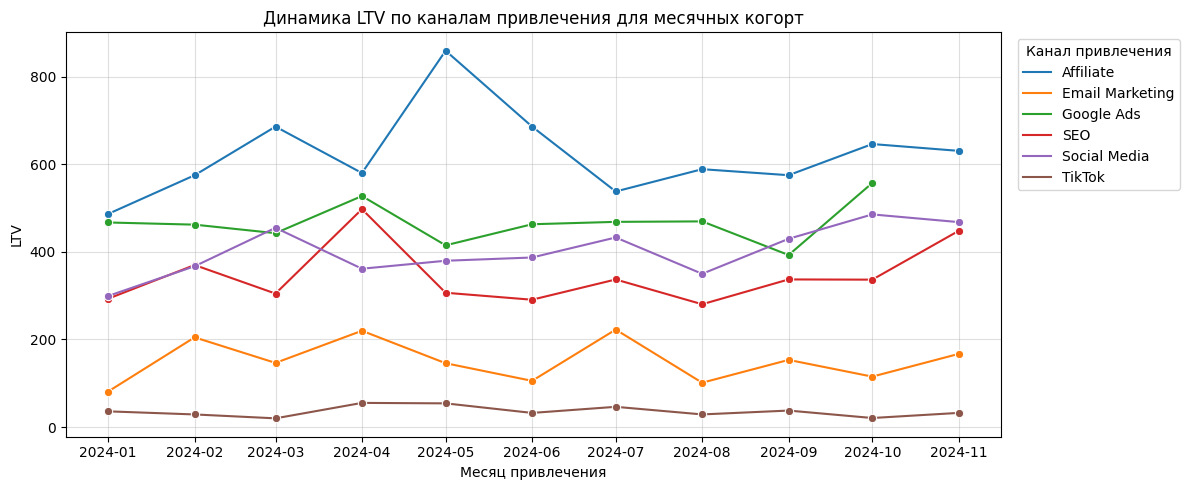

In [42]:
# Рисуем график
plt.figure(figsize=(12,5))
sns.lineplot(
    data=cohort_LTV_CAC[cohort_LTV_CAC['cohort_month']!='2024-12-01'],
    x='cohort_month',
    y='LTV',
    hue='acq_channel',
    marker='o'
)

plt.grid(alpha=.4)
plt.legend(title='Канал привлечения', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.title('Динамика LTV по каналам привлечения для месячных когорт')
plt.xlabel('Месяц привлечения')
plt.ylabel('LTV')
plt.tight_layout()

За месяц больше всего LTV набирают пользователи из канала `Affiliate`. `Google Ads` на втором месте по когортной выручке за месяц.

LTV `TikTok` трется около нуля.

Нужно смотреть окупаемость.

- **Payback Period для каналов привлечения**

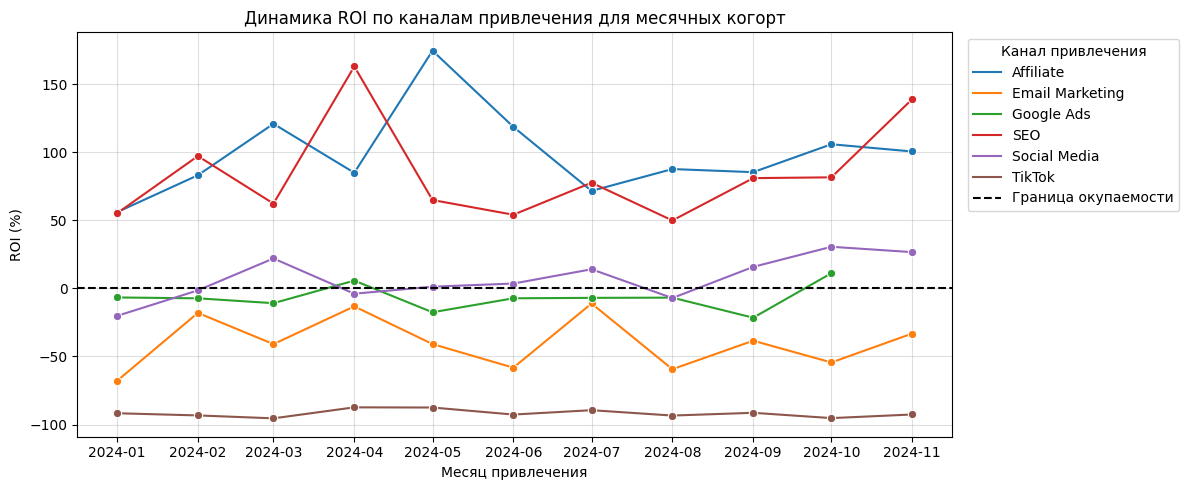

In [43]:
# Рисуем график
plt.figure(figsize=(12,5))
sns.lineplot(
    data=cohort_LTV_CAC[cohort_LTV_CAC['cohort_month']!='2024-12-01'],
    x='cohort_month',
    y='ROI',
    hue='acq_channel',
    marker='o'
)

# Рисуем линию окупаемости y=0
plt.axhline(y=0, color='black', linestyle='--', label='Граница окупаемости')

plt.grid(alpha=.4)
plt.legend(title='Канал привлечения', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.title('Динамика ROI по каналам привлечения для месячных когорт')
plt.xlabel('Месяц привлечения')
plt.ylabel('ROI (%)')
plt.tight_layout()

Успевают окупаться за месяц каналы: `Affiliate`, `SEO` и, почти всегда, `Social Media`.

`Google Ads` (кроме двух когорт), `Email Marketing` и `TikTok` не успевают окупаться за месяц. Хотя Google очень близок к тому, чтобы окупиться.

Для каналов, которые не окупаются за месяц рассмотрим более далекий горизонт. Например, 10 недель.

In [44]:
# Фильтруем датасеты для каналов привлечения, которые в последнее время не окупаются за 28 дней
channels = ['TikTok', 'Email Marketing', 'Google Ads']
orders_filt = cohort_orders[(cohort_orders['acq_channel'].isin(channels)) &
                     (cohort_orders['week_delta']).between(0,9)]
cohort_CAC_filt = cohort_CAC[cohort_CAC['acq_channel'].isin(channels)]

# Считаем суммарную выручку по неделям для каждого канала привлечения по недельным когортам
cohort_revenue = orders_filt.groupby(['acq_channel', 'cohort_month', 'week_delta'], as_index=False)['revenue'].sum()

# Отсортируем таблицу и посчтаем кумулятивную сумму выручки
cohort_revenue.sort_values(by=['acq_channel', 'cohort_month', 'week_delta'], inplace=True)
cohort_revenue['revenue_cumsum'] = cohort_revenue.groupby(['acq_channel', 'cohort_month'])['revenue'].cumsum()

# Объединяем таблицы и считаем LTV
cohort_LTV_CAC = pd.merge(cohort_revenue, cohort_CAC_filt, on=['acq_channel', 'cohort_month'])
cohort_LTV_CAC['LTV'] = cohort_LTV_CAC['revenue_cumsum'] / cohort_LTV_CAC['user_count']

# Считаем ROI 
cohort_LTV_CAC['ROI'] = (cohort_LTV_CAC['LTV'] - cohort_LTV_CAC['avg_CAC']) / cohort_LTV_CAC['avg_CAC']

# Форматируем поле first_week в строку, для отображения на тепловой карте
cohort_LTV_CAC['cohort_month'] = cohort_LTV_CAC['cohort_month'].astype(str)

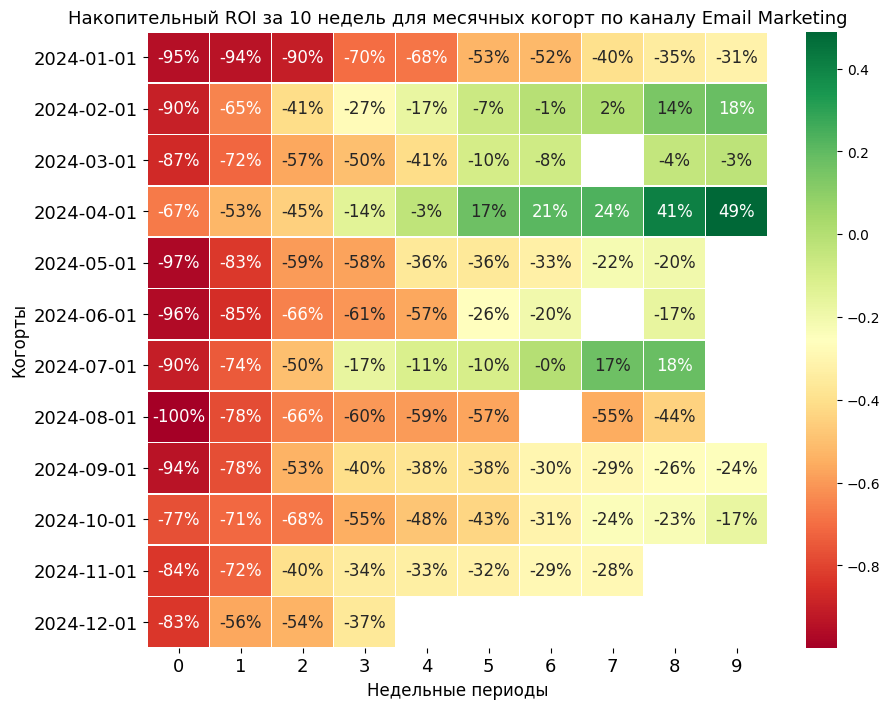

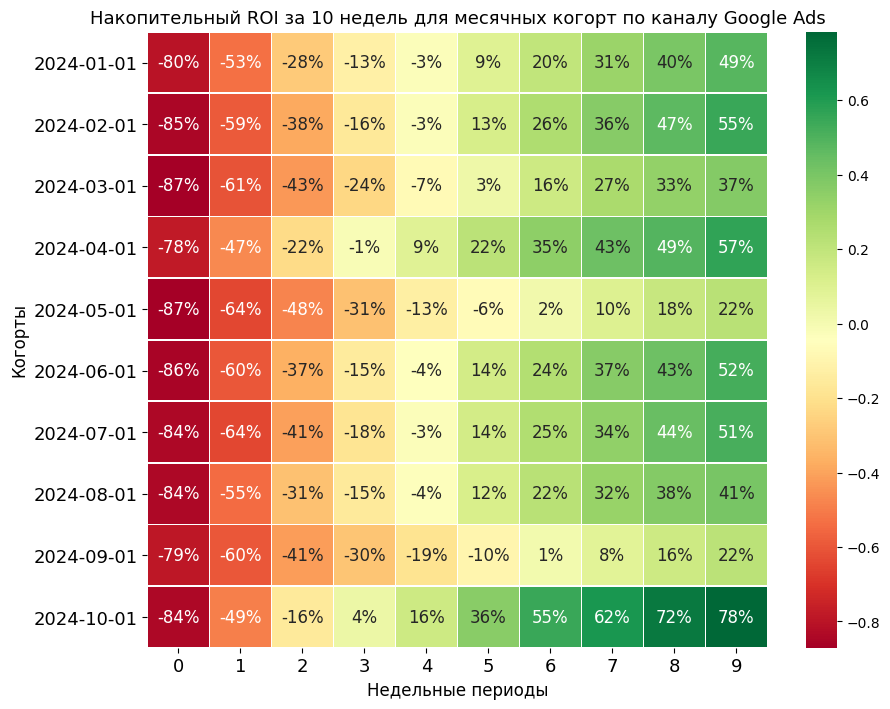

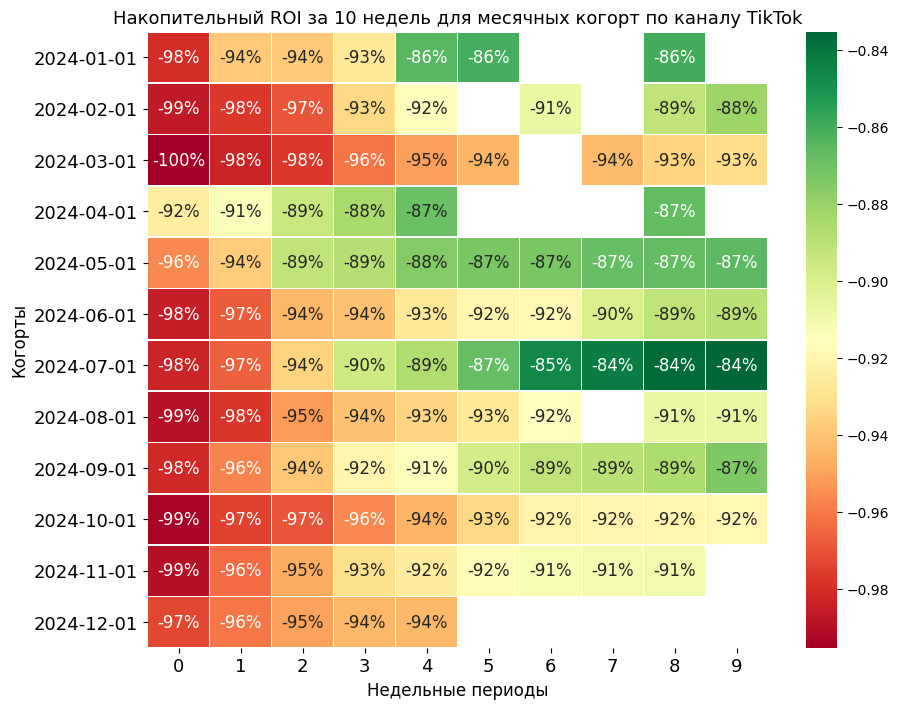

In [45]:
# Строим две тепловые карты через цикл
for channel in cohort_LTV_CAC['acq_channel'].unique():
    df_plot = cohort_LTV_CAC[cohort_LTV_CAC['acq_channel']==channel]

    pivot_data = pd.pivot_table(
        df_plot,
        index='cohort_month',
        columns='week_delta',
        values='ROI'
    )

    plt.subplots(figsize=(10,8))
    sns.heatmap(
        pivot_data,
        cmap='RdYlGn',
        annot=True,
        fmt='.0%',
        linewidth=0.5,
        annot_kws={"size": 12}
    )
    
    plt.title(f'Накопительный ROI за 10 недель для месячных когорт по каналу {channel}', fontsize=13)
    plt.xlabel('Недельные периоды', fontsize=12)
    plt.ylabel('Когорты', fontsize=12)
    plt.yticks(rotation=0)
    plt.tick_params(labelsize=13)

Канал `Email Marketing` на горизонте в 10 недель успел окупиться всего 3 раза.

`Google Ads`, хоть и не окупается за месяц, стабильно окупается за 6-7 недель. Последняя когорта вообще показала самые лучшие результаты по окупаемости при самом низком бюджете. Но, как я понимаю, с ним теперь невозможно сотрудничать.

`TikTok` даже близко не окупается и никогда не окупался за 10 недель.

## Выводы по этапу 4

**Общие выводы:**
- Серьезное снижение месячной прибыли с августа по декабрь, которое было найдено на этапе 2, по всей видимости произошло из-за того, что с каналом привлечения `Google Ads` больше невозможно работать.
- Резкое снижение конверсии в покупку, так же с августа по декабрь, является следствием привлечения через канал `TikTok` повышенного количества пользователей (как раз в эти месяцы) с низкими показателями конверсии в покупку.
- Канал `Email Marketing` крайне редко успевает окупаться даже за 10 недель.
- Канал `TikTok` вообще никогда не окупался за 10 недель и даже положительной динамики не прослеживается.
- `Google Ads` окупается в райное полутора месяцев, если это приемлемо, то я бы рекомендовал к нему вернуться (если возможно).
- Каналы привлечения `Affiliate` и `SEO` показывают отличные цифры окупаемости, если возможно, стоит попробовать их масштабировать.
- Канал `Social Media` только изредка не успевает окупаться за месяц, возможно его тоже стоит попробовать масштабировать, но период окупаемости у него заметно больше, чем у `Affiliate` и `SEO`.

## 5. Подготовка эксперимента и подведение его результатов

# Новые вводные (после этапа 4)
Команда продукта рассмотрела твои гипотезы и на основании этого решила влиять на конверсию при помощи финансовых стимуляций. Так как ситуация со снижением выручки срочная и безотлагательная, пока ты продолжал изучать данные, они подключили другого аналитика для подготовки дизайн документа, но само проведение эксперимента на тебе.


При формировании выводов допиши рекомендации по итогам теста и, если необходимо, опиши проблемы, присутствующие в эксперименте.


## Новые данные:

`pa_marketplace_events_AB.csv`

`pa_marketplace_orders_AB.csv`

`pa_marketplace_users_AB.csv`

## Результаты сплита лежат в таблице:

`pa_marketplace_AB_split_users.csv`

* user_id – id клиента
* group – группа, в которую попал клиент


# Дизайн эксперимента: Бонус на первую покупку для пользователей TikTok
## 1. Контекст и цель эксперимента
- **Бизнес-контекст:** Команда продукта запускает эксперимент, направленный на повышение конверсии среди пользователей, привлечённых через канал TikTok. Для стимулирования первой покупки пользователям будет предоставлен бонус на первую покупку.
- **Цель:** Проверить, влияет ли предоставление бонуса на первую покупку на конверсию и выручку среди пользователей TikTok.
- **Гипотеза:** Предоставление бонуса на первую покупку новым пользователям, привлеченным через TikTok, приведет к увеличению конверсии в первую покупку
---
## 2. Формат эксперимента
- **Тип эксперимента:** Сплит-роллинг (rolling split)
- **Канал:** Только пользователи, пришедшие с TikTok
- **Группы:**
    - **Контрольная (A):** пользователи TikTok без бонуса
    - **Тестовая (B):** пользователи TikTok с бонусом на первую покупку
- **Распределение:** Равномерное распределение новых пользователей TikTok между группами по дате регистрации
- **Период проведения:** 3 недели (фиксировано)

<div class="alert alert-info"> <b>Комментарий:</b> Видимо период проведения с 06.01 по 26.01. Было бы неплохо указать точные даты.</div>

---
## 3. Ключевые метрики
### Основная метрика
- **Конверсия в первую покупку** — доля пользователей, зарегистрировавшихся с TikTok и совершивших первую покупку
- *Цель:* увеличить конверсию с помощью бонуса
- *Критерий успеха:* статистически значимый рост конверсии в тестовой группе
### Вспомогательные метрики
- **ARPU** (средняя выручка на пользователя TikTok)
- **ARPPU** (средняя выручка на покупателя TikTok)
- **AOV** (средний чек TikTok)
### Барьерная метрика
- **Общая выручка от пользователей TikTok**
---
## 4. Размеры групп и запуск
- **Целевая аудитория:** только пользователи TikTok
- **Размеры групп:** определяются по фактическому трафику TikTok за период эксперимента
- **Комментарий:** запуск без предварительного расчёта мощности и MDE из-за срочности задачи

In [46]:
# Сразу преобразуем столбцы с датами в формат даты
events_AB = pd.read_csv('pa_marketplace_events_AB.csv', parse_dates=['event_date', 'event_week', 'event_month'])
orders_AB = pd.read_csv('pa_marketplace_orders_AB.csv', parse_dates=['order_date', 'order_week', 'order_month'])
users_AB = pd.read_csv('pa_marketplace_users_AB.csv', parse_dates=['registration_date', 'cohort_week', 'cohort_month'])
AB_split_users = pd.read_csv('pa_marketplace_AB_split_users.csv')

#### Рассмотрим датасеты

- **events_AB**

In [47]:
df_info(events_AB)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 831231 entries, 0 to 831230
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      831231 non-null  int64         
 1   user_id       831231 non-null  int64         
 2   event_date    831231 non-null  datetime64[ns]
 3   event_type    831231 non-null  object        
 4   os            831231 non-null  object        
 5   device        831231 non-null  object        
 6   product_name  409054 non-null  object        
 7   event_week    831231 non-null  datetime64[ns]
 8   event_month   831231 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 57.1+ MB


None

------------------------------------------------------------------------------------------


,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
0,3132,100,2024-01-01 15:23:56,page_view,iOS,mobile,NaN,2024-01-01,2024-01-01
1,3133,100,2024-01-01 15:24:01,product_view,iOS,mobile,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,100,2024-01-01 15:24:10,product_click,iOS,mobile,Куртка детская,2024-01-01,2024-01-01
3,3135,100,2024-01-01 15:25:10,add_to_cart,iOS,mobile,Балетки классические,2024-01-01,2024-01-01
4,3136,100,2024-01-01 15:25:46,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01


In [48]:
print(f'''
Датасет содержит информацию о событиях в период с {events_AB.event_date.min().date()} по {events_AB.event_date.max().date()}.
''')


Датасет содержит информацию о событиях в период с 2024-01-01 по 2025-01-26.



- **orders_AB**

In [49]:
df_info(orders_AB)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33280 entries, 0 to 33279
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       33280 non-null  int64         
 1   user_id        33280 non-null  int64         
 2   order_date     33280 non-null  datetime64[ns]
 3   product_name   33280 non-null  object        
 4   quantity       33280 non-null  int64         
 5   unit_price     33280 non-null  float64       
 6   total_price    33280 non-null  float64       
 7   category_name  33280 non-null  object        
 8   order_week     33280 non-null  datetime64[ns]
 9   order_month    33280 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 2.5+ MB


None

------------------------------------------------------------------------------------------


,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01


In [50]:
print(f'''
Датасет содержит информацию о заказах в период с {orders_AB.order_date.min().date()} по {orders_AB.order_date.max().date()}.
''')


Датасет содержит информацию о заказах в период с 2024-01-01 по 2025-01-26.



- **users_AB**

In [51]:
df_info(users_AB)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22196 entries, 0 to 22195
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            22196 non-null  int64         
 1   registration_date  22196 non-null  datetime64[ns]
 2   age                22196 non-null  int64         
 3   gender             22196 non-null  object        
 4   region             22196 non-null  object        
 5   acq_channel        22196 non-null  object        
 6   buyer_segment      22196 non-null  object        
 7   cohort_week        22196 non-null  datetime64[ns]
 8   cohort_month       22196 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 1.5+ MB


None

------------------------------------------------------------------------------------------


,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,18,2024-01-01 05:26:00,49,M,Екатеринбург,TikTok,one_time,2024-01-01,2024-01-01
1,22,2024-01-01 17:13:00,50,M,Санкт-Петербург,TikTok,one_time,2024-01-01,2024-01-01
2,26,2024-01-01 21:15:00,60,F,Москва,TikTok,rare,2024-01-01,2024-01-01
3,33,2024-01-01 14:43:00,31,M,Екатеринбург,TikTok,rare,2024-01-01,2024-01-01
4,39,2024-01-01 01:13:00,44,M,Санкт-Петербург,TikTok,rare,2024-01-01,2024-01-01


In [52]:
users_AB.acq_channel.unique()

array(['TikTok'], dtype=object)

В датасете пользователи только из Тик-Тока.

In [53]:
print(f'''
Датасет содержит информацию о пользователях, зарегистрированных в период с {users_AB.registration_date.min().date()} по {users_AB.registration_date.max().date()}.
''')


Датасет содержит информацию о пользователях, зарегистрированных в период с 2024-01-01 по 2025-01-26.



- **AB_split_users**

In [54]:
df_info(AB_split_users)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2968 entries, 0 to 2967
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  2968 non-null   int64 
 1   group    2968 non-null   object
dtypes: int64(1), object(1)
memory usage: 46.5+ KB


None

------------------------------------------------------------------------------------------


,user_id,group
0,44965,control
1,44967,control
2,44968,control
3,44969,treatment
4,44970,control


Проверим сплитование

In [55]:
# Проверим, не попали ли пользователи НЕ из Тик-Тока в датасет
AB_split_users[~AB_split_users['user_id'].isin(users_AB['user_id'].unique())].sum().sum()

0.0

In [56]:
# Проверяем уникальных пользователей
AB_split_users.user_id.nunique()

2968

In [57]:
# Среднее кол-во групп на пользователя 
AB_split_users.groupby('user_id')['group'].nunique().mean()

1.0

В датасете нет дубликатов и пользователей, которые попали в две группы одновременно

In [58]:
AB_split_users.group.value_counts()

control      1503
treatment    1465
Name: group, dtype: int64

In [59]:
(AB_split_users.group.value_counts()[0] - AB_split_users.group.value_counts()[1])/AB_split_users.group.value_counts()[1] * 100

2.5938566552901023

Контрольная группа на 2.6% больше, чем тестовая.

Можно проверить значимость этой разности с помощью метода хи-квадрат.

- **H0**: Различия в количестве пользователей между группами случайны и распределение соответствует ожидаемому. Система сплитования работает верно.
- **H1**: Различия в количестве пользователей статистически значимы и распределение не соответствует ожидаемому. Система сплитования работает некорректно.
- **Уровень значимости:** 0.05.

In [60]:
observed = AB_split_users.group.value_counts().to_list()
total = sum(observed)

# Ожидаемое распределение (50% на 50%)
expected = [total / 2, total / 2]

# Тест
chi2, p_value = chisquare(f_obs=observed, f_exp=expected)
print(f"P-value: {p_value:.4f}")

P-value: 0.4855


**P-value > 0.05**

Нет оснований отвергать нулевую гипотезу. Различия в количестве пользователей в группах статистически не значимы.

#### Анализ результатов теста

Нужно оставить в датасетах только пользователей, участвовавших в эксперименте.

In [61]:
# Объединим датасеты через inner
events_AB = events_AB.merge(AB_split_users, on='user_id')

df_info(events_AB)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4349 entries, 0 to 4348
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   event_id      4349 non-null   int64         
 1   user_id       4349 non-null   int64         
 2   event_date    4349 non-null   datetime64[ns]
 3   event_type    4349 non-null   object        
 4   os            4349 non-null   object        
 5   device        4349 non-null   object        
 6   product_name  2335 non-null   object        
 7   event_week    4349 non-null   datetime64[ns]
 8   event_month   4349 non-null   datetime64[ns]
 9   group         4349 non-null   object        
dtypes: datetime64[ns](3), int64(2), object(5)
memory usage: 373.7+ KB


None

------------------------------------------------------------------------------------------


,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month,group
0,844987,45076,2025-01-02 03:25:32,page_view,Android,tablet,NaN,2024-12-30,2025-01-01,control
1,844988,45076,2025-01-02 03:25:49,product_view,Android,tablet,Картина маслом,2024-12-30,2025-01-01,control
2,844989,45076,2025-01-02 03:26:23,product_click,Android,tablet,Сумка кожаная,2024-12-30,2025-01-01,control
3,844990,45076,2025-01-02 03:26:50,add_to_cart,Android,tablet,Дезодорант,2024-12-30,2025-01-01,control
4,844991,45076,2025-01-02 03:27:11,checkout_start,Android,tablet,NaN,2024-12-30,2025-01-01,control


In [62]:
print(f"Оставшийся диапазон дат: {events_AB.event_date.min().date()} - {events_AB.event_date.max().date()}")

Оставшийся диапазон дат: 2025-01-02 - 2025-01-26


Нужно оставить только даты периода эксперимента

In [63]:
events_AB_filt = events_AB[
    (events_AB['event_date']>='2025-01-06') &
    (events_AB['event_date']<='2025-01-26')
].copy()

In [64]:
# Оставим только пользователей, которые попали в тест
orders_AB = orders_AB.merge(AB_split_users, on='user_id')

df_info(orders_AB)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 255 entries, 0 to 254
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       255 non-null    int64         
 1   user_id        255 non-null    int64         
 2   order_date     255 non-null    datetime64[ns]
 3   product_name   255 non-null    object        
 4   quantity       255 non-null    int64         
 5   unit_price     255 non-null    float64       
 6   total_price    255 non-null    float64       
 7   category_name  255 non-null    object        
 8   order_week     255 non-null    datetime64[ns]
 9   order_month    255 non-null    datetime64[ns]
 10  group          255 non-null    object        
dtypes: datetime64[ns](3), float64(2), int64(3), object(3)
memory usage: 23.9+ KB


None

------------------------------------------------------------------------------------------


,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month,group
0,37141,45065,2025-01-01 11:57:43,Цепочка серебряная,3,7202.01,21606.03,Украшения и часы,2024-12-30,2025-01-01,treatment
1,37148,45081,2025-01-01 16:01:22,Куртка детская,2,2156.91,4313.82,Детская одежда,2024-12-30,2025-01-01,treatment
2,37149,45081,2025-01-01 16:01:22,Джинсы детские,1,873.16,873.16,Детская одежда,2024-12-30,2025-01-01,treatment
3,37147,45077,2025-01-02 04:59:13,Корм для кошек,2,851.39,1702.78,Зоотовары,2024-12-30,2025-01-01,treatment
4,37146,45077,2025-01-02 04:59:13,Чай черный,2,239.45,478.90,Продукты питания,2024-12-30,2025-01-01,treatment


In [65]:
print(f"Оставшийся диапазон дат: {orders_AB.order_date.min().date()} - {orders_AB.order_date.max().date()}")

Оставшийся диапазон дат: 2025-01-01 - 2025-01-26


Оставим даты периода эксперимента

In [66]:
orders_AB_filt = orders_AB[
    (orders_AB['order_date']>='2025-01-06') &
    (orders_AB['order_date']<='2025-01-26')
].copy()

In [67]:
# Посчитаем пользователей и покупателей в каждой группе и вычислим конверсию
users_count = AB_split_users.groupby('group').agg(total_users = ('user_id', 'nunique'))
buyers_count = orders_AB_filt.groupby('group').agg(total_buyers = ('user_id', 'nunique'))

AB_conversion = users_count.join(buyers_count).reset_index()
AB_conversion['CR'] = AB_conversion['total_buyers'] / AB_conversion['total_users']

display(AB_conversion)
print(f'''
Абсолютная разница в конверсии: {abs(AB_conversion['CR'][0] - AB_conversion['CR'][1]):.02%}
Относительная разница в конверсии: {(abs(AB_conversion['CR'][0] - AB_conversion['CR'][1]) / AB_conversion['CR'][0]):.02%}
''')

,group,total_users,total_buyers,CR
0,control,1503,14,0.009315
1,treatment,1465,99,0.067577



Абсолютная разница в конверсии: 5.83%
Относительная разница в конверсии: 625.49%



**Формулируем гипотезы:**
- **H0:** конверсии в контрольной и тестовой группах равны.
- **H1:** конверсия в контрольной группе меньше, чем в тестовой.
- **Уровень значимости:** 0.05.

In [68]:
# Проводим тест
z_score, p_value = proportions_ztest(AB_conversion.total_buyers.to_list(), AB_conversion.total_users.to_list(), alternative='smaller')

print(f"P-value: {p_value:.4f}")

P-value: 0.0000


**P-value < 0.05**

**Вывод:**
конверсия в тестовой группе значимо выросла.

#### Анализ вспомогательных и барьерной метрик
**Вспомогательные метрики**
- **ARPU** (средняя выручка на пользователя TikTok)
- **ARPPU** (средняя выручка на покупателя TikTok)
- **AOV** (средний чек TikTok)

**Барьерная метрика**
- **Общая выручка от пользователей TikTok**

Считаем метрики

In [69]:
# Добавим поле с выручкой
orders_AB_filt['revenue'] = orders_AB_filt['total_price'] * 0.05

# Считаем выручку, платящих пользователей и средний чек у каждой группы
metrics = orders_AB_filt.groupby('group').agg(
    total_revenue = ('revenue', 'sum'),
    paying_users = ('user_id', 'nunique'),
    AOV = ('total_price', 'mean')
)

# Общее кол-во активных пользователей в группе
active_users = AB_split_users.groupby('group').agg(total_users = ('user_id', 'nunique'))

# Соединяем по индексу
metrics = metrics.join(active_users).reset_index()

# Считаем метрики
metrics['AOV'] = metrics['AOV'].round(2)
metrics['ARPU'] = (metrics['total_revenue'] / metrics['total_users']).round(2)
metrics['ARPPU'] = (metrics['total_revenue'] / metrics['paying_users']).round(2)

metrics

,group,total_revenue,paying_users,AOV,total_users,ARPU,ARPPU
0,control,16799.4025,14,16799.40,1503,11.18,1199.96
1,treatment,164026.6405,99,16081.04,1465,111.96,1656.83


**Барьерная метрика** (общая выручка от пользователей TikTok) в тестовой группе выросла почти в 10 раз по сравнению с контрольной.

- **Исследуем вспомогательные метрики на стат. значимость**

Для начала проверим распределение чеков в датасете с заказами


Стандартное отклонение в контрольной группе: 15233.98
Стандартное отклонение в тестовой группе: 22491.40



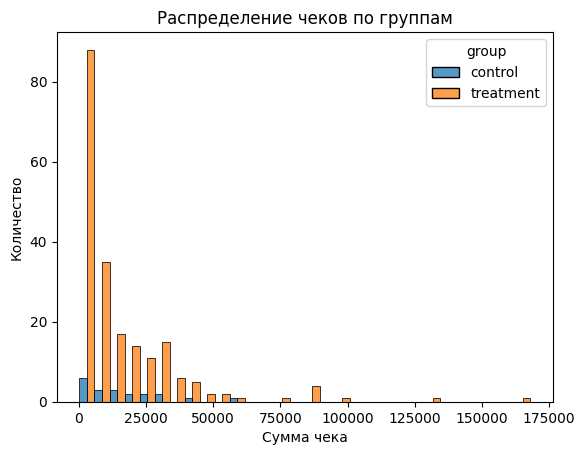

In [70]:
sns.histplot(data=orders_AB_filt, bins=30, multiple='dodge', x='total_price', hue='group')
plt.title('Распределение чеков по группам')
plt.xlabel('Сумма чека')
plt.ylabel('Количество')

print(f'''
Стандартное отклонение в контрольной группе: {orders_AB_filt[orders_AB_filt['group']=='control']['total_price'].std():.2f}
Стандартное отклонение в тестовой группе: {orders_AB_filt[orders_AB_filt['group']=='treatment']['total_price'].std():.2f}
''')

При такой маленькой выборке платящих пользователей в контрольной группе и, вероятно, распределении, которое далеко от нормального (оргомное количество нулей для метрики ARPU и большие хвосты справа), лучше всего использовать `бутстрап-метод` проверки стат. значимости для всех вспомогательных метрик. К тому же стандартные отклонения, вероятно, тоже будут сильно отличаться, как в распределении чеков.

Нужно проверить распределения выручки и для AOV нужно применить линеаризацию, так как это ratio-метрика со скошенным распределением.

Создадим таблицу с суммарной выручкой и средним линеаризированным чеком для каждого пользователя.

In [71]:
# Считаем для каждого покупателя суммарную выручку, суммарный чек и кол-во заказов
users_revenue = orders_AB_filt.groupby(['user_id', 'group'], as_index=False).agg(
    total_revenue = ('revenue', 'sum'),
    total_price_sum = ('total_price', 'sum'),
    orders = ('order_id', 'nunique')
)

# За основу берем AOV контрольной группы
global_aov_control = metrics.AOV[0]
users_revenue['aov_lin'] = users_revenue['total_price_sum'] - global_aov_control * users_revenue['orders']

# Присоединяем к events получившийся датасет слева и заполняем пропуски нулями
users_revenue = pd.merge(
    AB_split_users,
    users_revenue,
    on=['user_id', 'group'],
    how='left'
).fillna(0)

- **Проверим распределения суммарной выручки для всех пользователей и покупателей.**


Стандартное отклонение в контрольной группе: 138.78
Стандартное отклонение в тестовой группе: 675.07



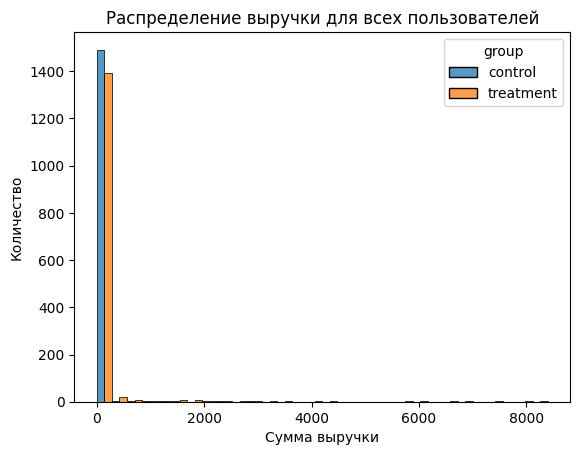

In [72]:
# Проверяем распределение выручки для всех пользователей
sns.histplot(data=users_revenue, bins=30, multiple='dodge', x='total_revenue', hue='group')
plt.title('Распределение выручки для всех пользователей')
plt.xlabel('Сумма выручки')
plt.ylabel('Количество')

print(f'''
Стандартное отклонение в контрольной группе: {users_revenue[users_revenue['group']=='control']['total_revenue'].std():.2f}
Стандартное отклонение в тестовой группе: {users_revenue[users_revenue['group']=='treatment']['total_revenue'].std():.2f}
''')

Огромное кол-во нулей и большие выбросы справа для тестовой группы. Стандартное отклонение отличается в 5 раз.


Стандартное отклонение в контрольной группе: 830.08
Стандартное отклонение в тестовой группе: 2054.81



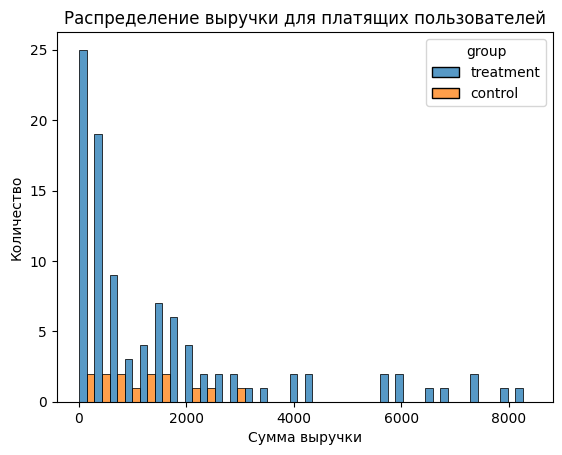

In [73]:
# Проверяем распределение выручки для платящих пользователей
sns.histplot(data=users_revenue[users_revenue['total_revenue']!=0], bins=30, multiple='dodge', x='total_revenue', hue='group')
plt.title('Распределение выручки для платящих пользователей')
plt.xlabel('Сумма выручки')
plt.ylabel('Количество')

print(f'''
Стандартное отклонение в контрольной группе: {users_revenue[(users_revenue['total_revenue']!=0) &
    (users_revenue['group']=='control')]['total_revenue'].std():.2f}
Стандартное отклонение в тестовой группе: {users_revenue[(users_revenue['total_revenue']!=0) &
    (users_revenue['group']=='treatment')]['total_revenue'].std():.2f}
''')

Очень много пользователей с маленькой выручкой и большой хвост справа.  Стандартное отклонение отличается в 2.5 раза.

**Вывод:** при таких вводных лучше всего использовать `бутстрап-метод разницы средних`.

**AOV с линеаризацией**

**Формулируем гипотезы:**
- **H0:** разница между средними значениями `линеаризарованного AOV` в группах равна нулю (*test - control = 0*).
- **H1:** разница между средними значениями `линеаризарованного AOV` в группах отличается от нуля (*test - control != 0*).

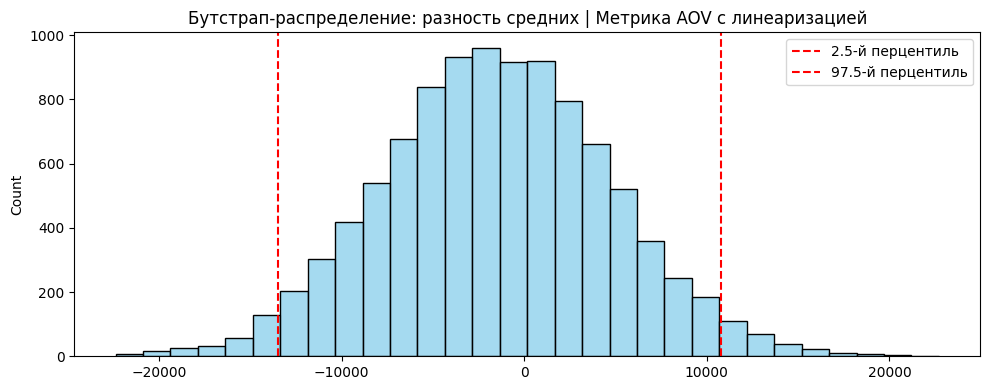

Доверительный интервал 95%: [-13502.77, 10752.27]


In [74]:
# AOV с линеаризацией
np.random.seed(42)

test = users_revenue[(users_revenue['aov_lin']!=0) &
                     (users_revenue['group']=='treatment')]['aov_lin']
control = users_revenue[(users_revenue['aov_lin']!=0) &
                        (users_revenue['group']=='control')]['aov_lin']
n_iterations = 10000
boot_diffs = []

# Считаем разность средних через цикл
for _ in range(n_iterations):
    boot_test = np.random.choice(test, size=len(test), replace=True)
    boot_control = np.random.choice(control, size=len(control), replace=True)

    boot_diffs.append(np.mean(boot_test) - np.mean(boot_control))

# Доверительный интервал
mean_diff_ci = np.percentile(boot_diffs, [2.5, 97.5])

# Рисуем график
plt.figure(figsize=(10, 4))

sns.histplot(boot_diffs, bins=30, color='skyblue', edgecolor='black')
plt.axvline(mean_diff_ci[0], color='red', linestyle='--', label='2.5-й перцентиль')
plt.axvline(mean_diff_ci[1], color='red', linestyle='--', label='97.5-й перцентиль')
plt.title("Бутстрап-распределение: разность средних | Метрика AOV с линеаризацией")
plt.legend()

plt.tight_layout()
plt.show()
print(f"Доверительный интервал 95%: [{mean_diff_ci[0]:.2f}, {mean_diff_ci[1]:.2f}]")

**Итог:** поскольку доверительный интервал включает в себя ноль, можно сделать вывод, что метрика `AOV` в тестовой группе `значимо не выросла` по сравнению с контрольной. 

**ARPPU**

**Формулируем гипотезы:**
- **H0:** разница между средними значениями `выручки на покупателя (ARPPU)` в группах равна нулю (*test - control = 0*).
- **H1:** разница между средними значениями `выручки на покупателя (ARPPU)` в группах отличается от нуля (*test - control != 0*).

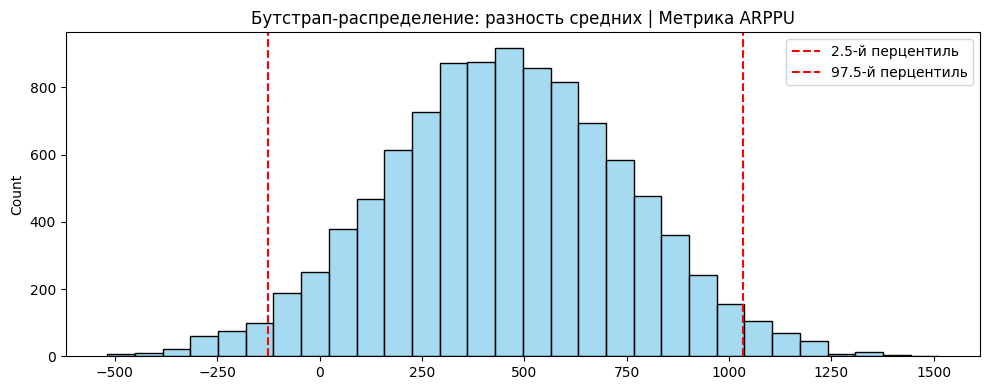

Доверительный интервал 95%: [-126.82, 1033.75]


In [75]:
# ARPPU
np.random.seed(42)

test = users_revenue[(users_revenue['total_revenue']!=0) &
                     (users_revenue['group']=='treatment')]['total_revenue']
control = users_revenue[(users_revenue['total_revenue']!=0) &
                        (users_revenue['group']=='control')]['total_revenue']
n_iterations = 10000
boot_diffs = []

# Считаем разность средних через цикл
for _ in range(n_iterations):
    boot_test = np.random.choice(test, size=len(test), replace=True)
    boot_control = np.random.choice(control, size=len(control), replace=True)

    boot_diffs.append(np.mean(boot_test) - np.mean(boot_control))

# Доверительный интервал
mean_diff_ci = np.percentile(boot_diffs, [2.5, 97.5])

# Рисуем график
plt.figure(figsize=(10, 4))

sns.histplot(boot_diffs, bins=30, color='skyblue', edgecolor='black')
plt.axvline(mean_diff_ci[0], color='red', linestyle='--', label='2.5-й перцентиль')
plt.axvline(mean_diff_ci[1], color='red', linestyle='--', label='97.5-й перцентиль')
plt.title("Бутстрап-распределение: разность средних | Метрика ARPPU")
plt.legend()

plt.tight_layout()
plt.show()
print(f"Доверительный интервал 95%: [{mean_diff_ci[0]:.2f}, {mean_diff_ci[1]:.2f}]")

**Итог:** доверительный интервал проходит через 0, значит метрика `ARPPU` в тестовой группе `значимо не выросла` по сравнению с контрольной. 

**ARPU**

**Формулируем гипотезы:**
- **H0:** разница между средними значениями `выручки на пользователя (ARPU)` в группах равна нулю (*test - control = 0*).
- **H1:** разница между средними значениями `выручки на пользователя (ARPU)` в группах отличается от нуля (*test - control != 0*).

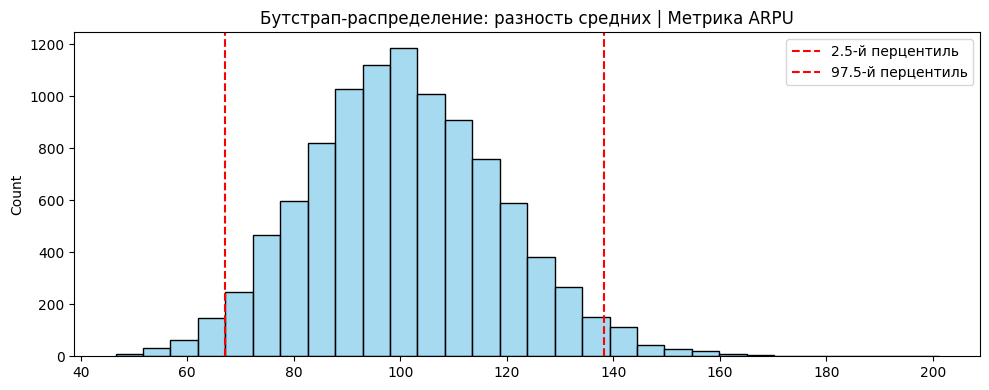

Доверительный интервал 95%: [67.15, 138.28]


In [76]:
# ARPU
np.random.seed(42)

test = users_revenue[users_revenue['group']=='treatment']['total_revenue']
control = users_revenue[users_revenue['group']=='control']['total_revenue']
n_iterations = 10000
boot_diffs = []

# Считаем разность средних через цикл
for _ in range(n_iterations):
    boot_test = np.random.choice(test, size=len(test), replace=True)
    boot_control = np.random.choice(control, size=len(control), replace=True)

    boot_diffs.append(np.mean(boot_test) - np.mean(boot_control))

# Доверительный интервал
mean_diff_ci = np.percentile(boot_diffs, [2.5, 97.5])

# Рисуем график
plt.figure(figsize=(10, 4))

sns.histplot(boot_diffs, bins=30, color='skyblue', edgecolor='black')
plt.axvline(mean_diff_ci[0], color='red', linestyle='--', label='2.5-й перцентиль')
plt.axvline(mean_diff_ci[1], color='red', linestyle='--', label='97.5-й перцентиль')
plt.title("Бутстрап-распределение: разность средних | Метрика ARPU")
plt.legend()

plt.tight_layout()
plt.show()
print(f"Доверительный интервал 95%: [{mean_diff_ci[0]:.2f}, {mean_diff_ci[1]:.2f}]")

**Итог:** доверительный интервал лежит справа от нуля. Это говорит о том, что метрика `ARPU` в тестовой группе `значимо выросла` по сравнению с контрольной. 

## Выводы по этапу 5

**Выводы:**
- Основная метрика (`конверсия в покупку`) `показала стат. значимый рост` в тестовой группе. Относительный рост составил 625%.
- Вспомогательные метрики `AOV` и `ARPPU` в тестовой группе `не показали статистически значимый рост` по сравнению с контрольной. Т.е. покупатели не стали заказывать больше.
- Вспомогательная метрика `ARPU` `показала стат значимый рост`. Т.е. в среднем выручка на каждого пользователя увеличилась. Покупатели не стали заказывать больше - доля покупателей увеличилась.
- Барьерная метрика (`общая выручка на пользователей TikTok`) `увеличилась в 10 раз`. Хотя тут бы еще стоило посмотреть какой бюджет был выделен на стимулирование первой покупки (если под стимуляцией подразумевалась скидка или промокод).